## Predictive Modelling for Network Monitoring: Case Study of Telstra Telecommunication Network

## Expected Objectives of the Telstra Fault Severity Prediction Project
- Predict Network Fault Severity Accurately: build a machine learning model that can correctly classify the severity level of network faults using available network event and resource data.

- Identify Important Fault Contributors: determine which features such as location, event type, resource type, severity type and log features contribute most to predicting fault severity.

- Improve Network Maintenance Decisions: help Telstra network engineers prioritize critical faults faster so that severe faults can be attended to before they escalate.

- Reduce Service Downtime: enable early detection and classification of serious network problems, thereby reducing interruptions experience by customers.

- Support Data-Driven Telecom Operations: provide Telstra with an intelligent predictive system that improves operational efficiency and enhances network reliability.

## Expected Outcomes of the Project
- A trained predictive model capable of classifying faults into severity levels.

- Identification of the most influential network features affecting fault severity.

- Improved understanding of fault patterns and network behaviour through Exploratory Data Analysis (EDA).

- Better fault response planning and resource allocation for Telstra network engineers.

- Reduced network outage impact through faster prediction and prioritisation of severe faults.

- A comparison of multiple machine learning models to determine the best-performing model.

## Performance Metrics
1. Accuracy: measures how many predictions made by the model are correct out of all predictions.
   Accuracy =        TP+TN/TP+TN+FP+FN
   - TP = True positive
   - TN = True Negative
   - FP = False Positive
   - FN = False Negative

2. Precision: measures how many of the faults predicted as severe are actually severe.
   Precision = TP/TP+FP
   Interpretation: high precision means the model makes fewer false alarms.

3. Recall (Sensitivity): this measures how many actual severe faults the model successfully detects.
   Recall = TP/TP+FN
   Interpretation: high recall means the model misses very few severe faults.

4. F1-Score: is the balance between precision and recall.
   F1 = 2 x (precision x recall / precision + recall)
   Interpretation: It is useful when the dataset is imbalanced especially when some fault severity classes appear more than others.

In [2]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\Philip\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
!pip install shap lime

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\Philip\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\Philip\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [128]:
#Import the neccessary libraries for the task
import numpy as np   
import pandas as pd   
import matplotlib.pyplot as plt   
import seaborn as sns
import shap
import joblib
import lime
import streamlit as st
import lime.lime_tabular
sns.set_style("white")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from eli5.sklearn import PermutationImportance
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_selection import (VarianceThreshold, SelectKBest, chi2, mutual_info_classif, RFE)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline as ImPipeline
from imblearn.over_sampling import SMOTE
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

In [6]:
#Read in the train data of Telstra and view the features
train = pd.read_csv('train..csv')
train

,id,location,fault_severity
0,14121,location 118,1
1,9320,location 91,0
2,14394,location 152,1
3,8218,location 931,1
4,14804,location 120,0
...,...,...,...
7376,870,location 167,0
7377,18068,location 106,0
7378,14111,location 1086,2
7379,15189,location 7,0


In [7]:
#Read in the severity type data of Telstra and view the features
st = pd.read_csv('severity_type..csv')
st

,id,severity_type
0,6597,severity_type 2
1,8011,severity_type 2
2,2597,severity_type 2
3,5022,severity_type 1
4,6852,severity_type 1
...,...,...
18547,3761,severity_type 1
18548,8720,severity_type 1
18549,6488,severity_type 2
18550,878,severity_type 2


In [8]:
#Read in the resource type of Telstra and view the features
rt = pd.read_csv('resource_type..csv')
rt

,id,resource_type
0,6597,resource_type 8
1,8011,resource_type 8
2,2597,resource_type 8
3,5022,resource_type 8
4,6852,resource_type 8
...,...,...
21071,3761,resource_type 8
21072,8720,resource_type 8
21073,6488,resource_type 8
21074,878,resource_type 8


In [9]:
#Read in the log feature of Telstra and view the features
lf = pd.read_csv('log_feature..csv')
lf

,id,log_feature,volume
0,6597,feature 68,6
1,8011,feature 68,7
2,2597,feature 68,1
3,5022,feature 172,2
4,5022,feature 56,1
...,...,...,...
58666,8720,feature 209,1
58667,6488,feature 54,3
58668,878,feature 62,1
58669,4464,feature 209,1


In [10]:
#Read in the event type of Telstra and view the features
et = pd.read_csv('event_type..csv')
et

,id,event_type
0,6597,event_type 11
1,8011,event_type 15
2,2597,event_type 15
3,5022,event_type 15
4,5022,event_type 11
...,...,...
31165,3761,event_type 11
31166,8720,event_type 11
31167,6488,event_type 11
31168,878,event_type 11


In [11]:
#Merge the individual data of Telstra and view the features
t = train.merge(st, on='id', how='left')
t1 = t.merge(rt, on='id', how='left')
t2 = t1.merge(lf, on='id', how='left')
t3 = t2.merge(et, on='id', how='left')
t3

,id,location,fault_severity,severity_type,resource_type,log_feature,volume,event_type
0,14121,location 118,1,severity_type 2,resource_type 2,feature 312,19,event_type 34
1,14121,location 118,1,severity_type 2,resource_type 2,feature 312,19,event_type 35
2,14121,location 118,1,severity_type 2,resource_type 2,feature 232,19,event_type 34
3,14121,location 118,1,severity_type 2,resource_type 2,feature 232,19,event_type 35
4,9320,location 91,0,severity_type 2,resource_type 2,feature 315,200,event_type 34
...,...,...,...,...,...,...,...,...
61834,15189,location 7,0,severity_type 1,resource_type 8,feature 55,10,event_type 11
61835,15189,location 7,0,severity_type 1,resource_type 8,feature 70,1,event_type 11
61836,17067,location 885,0,severity_type 1,resource_type 8,feature 81,1,event_type 11
61837,17067,location 885,0,severity_type 1,resource_type 8,feature 191,1,event_type 11


In [12]:
#Check for data completeness, the dataset is clean, no missing value.
missing_values = t3.isnull().sum()
missing_values

id                0
location          0
fault_severity    0
severity_type     0
resource_type     0
log_feature       0
volume            0
event_type        0
dtype: int64

In [13]:
# Checking for duplicate
t3.duplicated().sum()

np.int64(0)

In [14]:
# Eliminating duplicate log_feature to recognise only the one with the highest volume
lfm = t3.loc[t3.groupby('id')['volume'].idxmax()]
#Group others by best of judgement
t3a = t3.groupby('id').agg({
    'location': 'first', #since this isn't duplicate
    'fault_severity': 'first', #since this isn't duplicate
    'severity_type': 'max', #since the duplicate here is graded from low severity to high severity, the max (highest severity) will serve better purpose than other forms of aggregate 
    'resource_type': 'max', 
    'event_type': 'max',
    'volume': 'max' #since volume represents the number of times the event occured, the max was used as sum would have aggregated unrealistics numbers and make our volume bogus
}).reset_index()

t4 = t3a.merge(
    lfm[['id', 'log_feature']],
    on='id',
    how='left'
)
t4

,id,location,fault_severity,severity_type,resource_type,event_type,volume,log_feature
0,1,location 601,1,severity_type 1,resource_type 8,event_type 13,2,feature 68
1,5,location 460,0,severity_type 2,resource_type 2,event_type 35,11,feature 312
2,6,location 332,1,severity_type 2,resource_type 2,event_type 34,1,feature 227
3,8,location 243,0,severity_type 2,resource_type 2,event_type 35,5,feature 309
4,13,location 418,0,severity_type 2,resource_type 2,event_type 35,1,feature 232
...,...,...,...,...,...,...,...,...
7376,18539,location 147,0,severity_type 1,resource_type 2,event_type 35,1,feature 301
7377,18542,location 495,0,severity_type 2,resource_type 2,event_type 35,9,feature 312
7378,18543,location 998,1,severity_type 1,resource_type 8,event_type 11,1,feature 54
7379,18548,location 278,0,severity_type 2,resource_type 2,event_type 35,4,feature 232


In [15]:
# Encode the Telstra Data (Extracting numbers from text column)
t4['location'] = t4['location'].str.extract('(\\d+)').astype(int)
t4['severity_type'] = t4['severity_type'].str.extract('(\\d+)').astype(int)
t4['resource_type'] = t4['resource_type'].str.extract('(\\d+)').astype(int)
t4['log_feature'] = t4['log_feature'].str.extract('(\\d+)').astype(int)
t4['event_type'] = t4['event_type'].str.extract('(\\d+)').astype(int)
t4

,id,location,fault_severity,severity_type,resource_type,event_type,volume,log_feature
0,1,601,1,1,8,13,2,68
1,5,460,0,2,2,35,11,312
2,6,332,1,2,2,34,1,227
3,8,243,0,2,2,35,5,309
4,13,418,0,2,2,35,1,232
...,...,...,...,...,...,...,...,...
7376,18539,147,0,1,2,35,1,301
7377,18542,495,0,2,2,35,9,312
7378,18543,998,1,1,8,11,1,54
7379,18548,278,0,2,2,35,4,232


In [16]:
#Check the length of the data shape and columns
print("Dimension of Telstra Predictive Data Project: {}".format(t4.shape))
print("Total data points:",t4.shape[0])
print("Total number of features are:", t4.shape[1])

Dimension of Telstra Predictive Data Project: (7381, 8)
Total data points: 7381
Total number of features are: 8


In [17]:
#check the datatype of features
t4.dtypes

id                int64
location          int64
fault_severity    int64
severity_type     int64
resource_type     int64
event_type        int64
volume            int64
log_feature       int64
dtype: object

<div class="alert alert-info" style="background-color:#E88209; color:white; padding:0px 10px; border-radius:5px;"><h2 style='margin:10px 5px'>Exploratory Data Analysis (EDA) with Predictive Modelling for Network Monitoring: Telstra as Case Study</h2>
</div>

## Data Description

Telecommunication networks are critical infrastructure and disruptions can significantly impact service delivery and customer satisfaction. The Telstra Network disruptions dataset captures various network events, resource usage and severity indicators with the goal of predicting the fault severity of network issues. Accurate prediction of fault severity  helps prioritize response efforts and improve operational efficiency.

The Telstra Network Disruptions dataset is structures around multiple relational tables each capturing different aspects of network behavior such as events, resources, severity types and log features. The primary task is a multi-class classification problem, where the target variables indicates the seriousness of a network fault.  

Data Attribute Information:

- ID number: Unique identifier for each network event.
- Location: Encoded identifier representing the location of the fault
- Fault Severity: (0 = low severity, 1 = medium severity and 2 = high severity)
- Class distribution: 4784 low severity, 1871 medium severity and 726 high severity.

- Other Attributes:
- a) Event type: This is a categorical variable which represents the type of event associated with the fault.
- b) Log feature: This represents the specific network-related features recorded during the event.
- c) Volume: This indicates the frequency of the corresponding log feature.
- d) Resource type: This identifies the type of resource involved in the network event.
- e) Severity type: This encodes predefined severity categories assigned internally within the system.

In [18]:
#Checking for numbers of unique values in the dataset
t4.nunique()

id                7381
location           929
fault_severity       3
severity_type        5
resource_type        8
event_type          40
volume             221
log_feature        176
dtype: int64

In [19]:
#Check for the details/breakdown of our target feature
t4['fault_severity'].value_counts()

fault_severity
0    4784
1    1871
2     726
Name: count, dtype: int64

## Descriptive statistics

In [20]:
t4.drop(columns=["id"]).describe()

,location,fault_severity,severity_type,resource_type,event_type,volume,log_feature
count,7381.000000,7381.00000,7381.000000,7381.000000,7381.000000,7381.000000,7381.000000
mean,624.313779,0.45021,1.657770,5.393443,24.525539,14.850020,185.202547
std,320.622091,0.66656,0.760966,2.973402,12.434012,36.986764,103.216770
min,1.000000,0.00000,1.000000,1.000000,2.000000,1.000000,1.000000
25%,374.000000,0.00000,1.000000,2.000000,13.000000,2.000000,82.000000
50%,665.000000,0.00000,2.000000,8.000000,20.000000,4.000000,193.000000
75%,893.000000,1.00000,2.000000,8.000000,35.000000,13.000000,307.000000
max,1126.000000,2.00000,5.000000,10.000000,54.000000,877.000000,378.000000


## Interpretation of Descriptive Statistics

General Notes:
    
- Count: This shows the number of non-null entries for each feature (column) and all features having 7381 entries indicates that there are no missing values in the dataset after merging and preprocessing.

- Mean: Gives the average value for each feature (column) and helps understand the central tendency of the data.

- Standard Deviation (std): The standard deviation measures how spread out the values are. A higher standard deviation means higher variability within the feature.

- Minimum (min) and Maximum (max): The minimum and maximum shows the full range of values within each feature and helps identify outliners.

- Percentiles (25%, 50%, 75%): These are the values below which a certain percentage of the data falls, providing insight into the distribution. They describe the distribution of the data revealing skewness and concentration of values. 25% represents lower quartile, 50% represents the median and 75% represents the upper quartile.

Interpretation for Specific features (Columns): 

1. Fault Severity (Target Feature)
- Mean: 0.450 implies that most network faults belong to the low severity class.

- Std: 0.667 indicates variability across severity level.

- Min/Max: 0 to 2 confirms that the target variable contains all 3 severity classes.

- 25%, 50% and 75% of 0, 0, 1 respectively indicates that half of the observations are low severity faults (0), showing class imbalance toward lower fault levels.

2. Location
- Mean: 624.31 the value here has no meaning as locations were categorical data encoded numerically.

- Std: 320.62 the large spread indicates that fault events are distributed across many different locations.

- Min/Max: 1 to 1126 shows that the dataset contains a very high number of unique locations.

- 25%, 50% and 75% of 374, 665, 893 respectively indicates that faults are broadly distributed across the network infrastructure rather than concentrated in a few locations.

3. Severity Type
- Mean: 1.66 implies that most observations are centred around severity types 1 and 2.

- Std: 0.76 indicates moderate variation across severity categories.

- Min/Max: 1 to 5 confirms that five severity categories exists in the dataset.

- 25%, 50% and 75% of 1, 2, 2 respectively suggests that the majority of records belong to the lower internal severity types.

4. Resource Type
- Mean: 5.39 shows that on average, resouce types are centred around the middle to upper encoded categories.

- Std: 2.97 indicates substantial diversity in the resources associated with network faults.

- Min/Max: 1 to 10 indicates 10 distinct resource categories involved in network events.

- 25%, 50% and 75% of 2, 8, 8 respectively indicates that resource type 8 appears very frequently in the dataset.

5. Event Type
- Mean: 24.53 shows that the average event type lies near the middle of the encoded event categories.

- Std: 12.43 showing high variability indicates that different event types are associated with the network disruptions.

- Min/Max: 2 to 54 shows a wide range of network event categories.

- 25%, 50% and 75% of 13, 20, 35 respectively indicates that event types are fairly spread across the dataset, with no extremen concentration around a single group.

6. Log Feature
- Mean: 185.20 the average encoded log feature lies near the centre of the available feature range.

- Std: 103.22 indicates high variability in the types of network log features recorded.

- Min/Max: 1 to 378 shows the dataset contains a large number of distinct log features.

- 25%, 50% and 75% of 82, 193, 307 respectively confirms that log features are broadly distributed across many categories.

7. Volume
- Mean: 14.85 indicates that on average, the recorded log feature is about 15.

- Std: 36.99 the high standard deviation compared to the mean suggests the presence of strong outliers and highly uneven volume distribution.

- Min/Max: 1 to 877 this extremely wide range confirms that some network events generates exceptionally large log volumes.

- 25%, 50% and 75% of 2, 4, 13 respectively indicates that the distribution is heavily right skewed with a few extreme high volume cases since 75% of the values are below13 whereas the maximum is 877.

Key Observations:
- Fault Severity Imbalance: As seen from the mean of the fault severity, there is an imbalance between low, medium and high severity cases, which could influence our model's performance, therefore it is crucial to account for this in data preprocessing.

- Variability in Fault Characteristics: Features such as event type, resource type and log features have high variability (as seen from the standard deviation). This indicates that they may carry strong predictive signals.

- Significant outliers: Volume contains significant outliers and may require transformation.

## Checking Data Balance

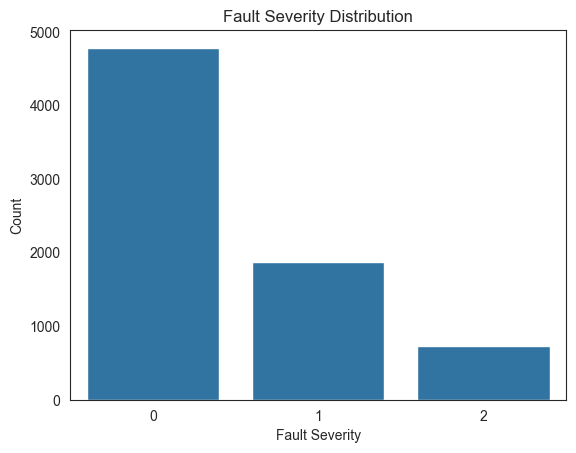

fault_severity
0    4784
1    1871
2     726
Name: count, dtype: int64

In [21]:
#check for Fault Severity Distribution to see if they are balanced or imbalanced
sns.countplot(x='fault_severity', data=t4)
plt.title("Fault Severity Distribution")
plt.xlabel('Fault Severity')
plt.ylabel('Count')
plt.show()
t4['fault_severity'].value_counts()

## Interpretation of Data Imbalance on Fault Severity Distribution
The dataset is imbalanced towards the lower-severity faults as 4781 data points representing 61.82% had low severity while 1871 representing 21.35% had medium severity and 726 data points being 9.83% had high severity.

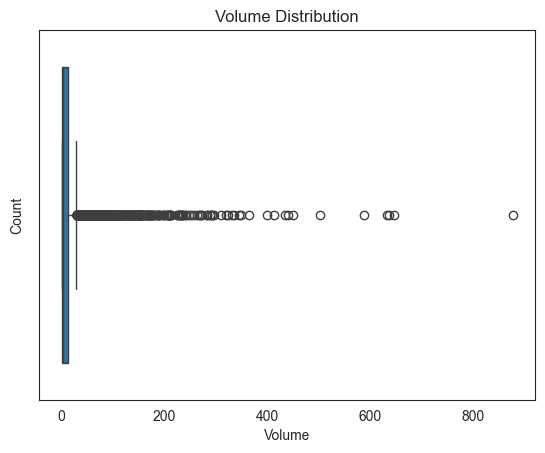

In [22]:
#check for Volume Distribution to see if they are balanced or imbalanced
sns.boxplot(x=t4['volume'])
plt.title("Volume Distribution")
plt.xlabel('Volume')
plt.ylabel('Count')
plt.show()

### Interpretation of Volume Distribution Box Plot
The boxplot shows that the volume feature is heavily right-skewed with several extreme outliers. Most observations are concentrated at lower volume values, while a few records contain exceptionally high volumes. This suggests that transformation techniques such as log transformation may improve model performance.

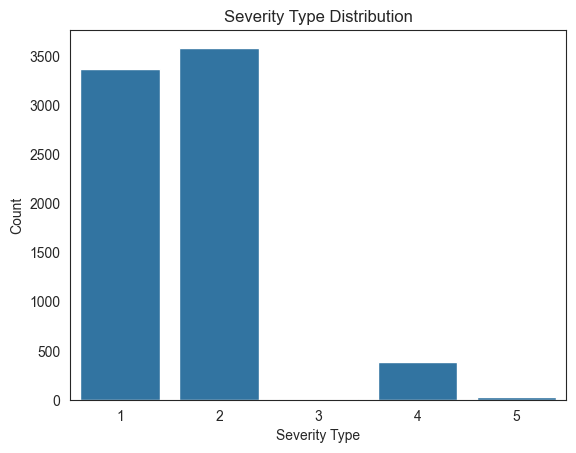

severity_type
2    3591
1    3375
4     388
5      23
3       4
Name: count, dtype: int64

In [23]:
#check for Severity Type Distribution to see if they are balanced or imbalanced
sns.countplot(x='severity_type', data=t4)
plt.title("Severity Type Distribution")
plt.xlabel('Severity Type')
plt.ylabel('Count')
plt.show()
t4['severity_type'].value_counts()

## Interpretation of Data Imbalance on Severity Type Distribution
The dataset is imbalanced towards the low internal severity classifications as severity type 2 with the highest datat points had 3591 data points representing 48.65% had low severity classification and severity type 1 had 3375 data point representing 45.72% had very low severity classification while 415 data points representing 5.62% had between moderate to very high severity severity type.

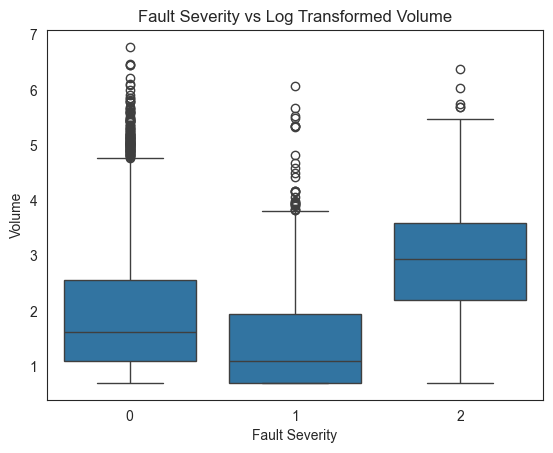

In [24]:
## Checking Fault Severity against Log Transformed Volume
plt.figure()
sns.boxplot(x='fault_severity', y=np.log1p(t4['volume']), data=t4)
plt.title('Fault Severity vs Log Transformed Volume')
plt.xlabel('Fault Severity')
plt.ylabel('Volume')
plt.show()

## Interpretation of the Boxplot: Fault Severity vs Volume
This boxplot compares the distribution of volume across the three fault secerity classes (0, 1 and 2).

- Fault severity 2 has the highest volume among all the classes suggesting that more severe network faults are generally associated with higher network values.

- Fault severity 1 has the lowest median volume indicating comparatively smaller network activity or impact.

- Fault severity 0 falls between severity 1 and 2.

### Spread and Variability
- Severity 2 also shows a wider spread (larger interquartile range), meaning volume values vary greatly for highly severe faults.

- Severity 1 is more compact, indicating more consistency in volume values.

### Presence of outliers
All three classes contains many outliers especially
- Severity 0
- Severity 1
This implies that:
- Some network fault cases have extremely high volume values compared to the majority.

- The data is right skewed.

### Overall Insight
The boxplot reveals that:
- Higher fault severity levels tend to have higher volume distributions.

- The relationship may be non-linear rather than purely linear.

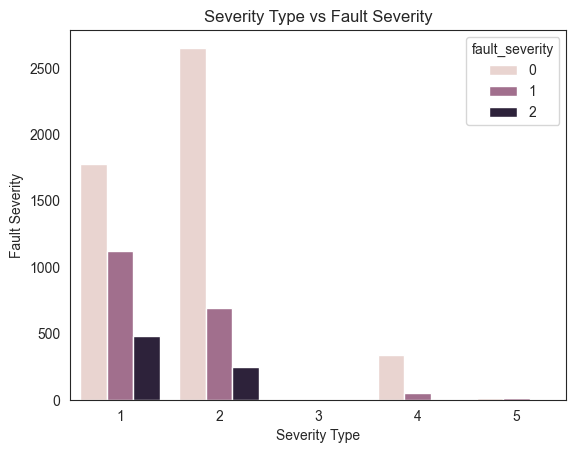

In [25]:
# check for Severity Type vs Fault Severity
sns.countplot(x='severity_type', hue='fault_severity', data=t4)
plt.title("Severity Type vs Fault Severity")
plt.xlabel('Severity Type')
plt.ylabel('Fault Severity')
plt.show()

## Interpretation of the Count Plot: Severity Type and Fault Severity
This graph shows how different severity_type categories are distributed across the target classes (fault_severity).
- Severity Type 1 and 2 dominates the dataset. Most fault records belong to these two categories.

- Severity Type 2 has the highest number observations overall especially for:
   - fault severity 0
   - fault severity 1

- Fault severity 0 consistently has the highest frequency across nearly all severity types. This indicates the dataset is somewhat imbalanced toward lower fault severity cases.

### Rare Categpries
- Severity types 3 and 5 have extremely few observations.

- Severity type 4 appears mostly associated with fault 0.
This suggests:
- Some severity types are rare events.

- Rare categories may contribute less during model traininig.

### Relationship Between Severity Type and Fault Severity
- As severity type changes from 1 to 2, the count distribution across fault severity classes also changes noticeably.

- There is no perfectly increasing trend.

## Correlation Matrix: Understanding Relationships Between Variables

- A correlation matrix is a powerful tool used in data analysis to examine the relationships between pairs of variables in a dataset. It displays the correlation coefficients, which indicate the strength and direction of linear relationships between variables. It provides key values such as identifying relationships, detecting multicollinearity, feature selection, prioritze variables, testing assumptions, visualization and interpretation.

In summary, the correlation matrix serves as a fundamental tool in exploratory data analysis and model development, providing insights into variable relationships, guiding feature selection and validating assumptions. 

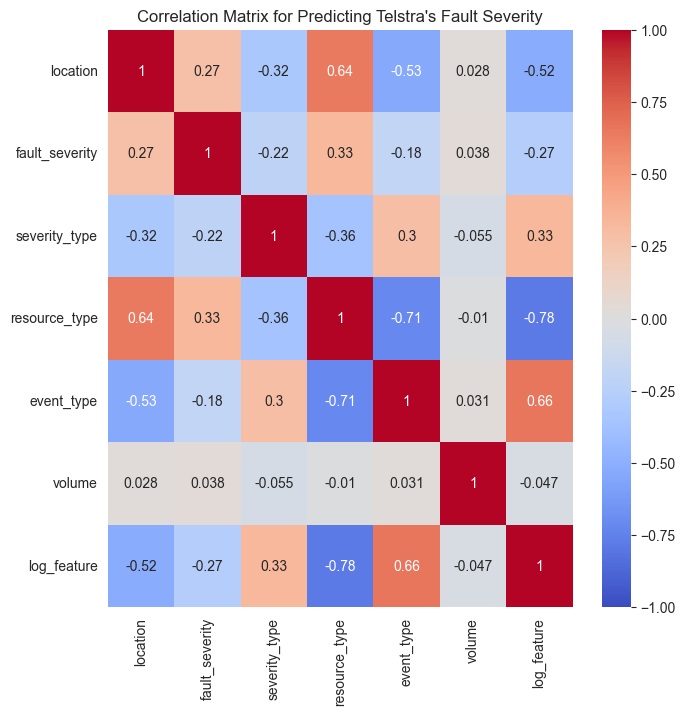

In [26]:
# Create a large figure to accommodate the heatmap
plt.figure(figsize=(7.5, 7.5))  # Initializes a new figure with a size of 15x15 inches for better visibility of the heatmap.

# Exclude the 'id' column and compute the correlation matrix
correlation_matrix = t4.drop(columns=['id']).corr()  # Drop the 'id' column and calculate the correlation matrix for the remaining columns.

# Create the heatmap
heatmap = sns.heatmap(correlation_matrix, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
# Generates a heatmap using Seaborn's heatmap function.
# The correlation matrix is calculated without the 'id' column.
# vmin and vmax set the limits of the color scale to -1 and 1, respectively, representing the range of correlation coefficients.
# annot=True adds the correlation coefficient values on the heatmap for easier interpretation.
# cmap='coolwarm' specifies the color palette for the heatmap, transitioning from cool colors for negative correlations to warm colors for positive correlations.

# Set plot title
plt.title("Correlation Matrix for Predicting Telstra's Fault Severity")
# Assigns a title to the heatmap for context, indicating that the correlations are derived from the dataset.

# Save the plot as a PNG file with a white background
heatmap.figure.savefig('correlation_matrix.png', bbox_inches='tight', pad_inches=0, dpi=300, facecolor='w')
# Saves the generated heatmap as a PNG file named 'correlation_matrix.png'.
# bbox_inches='tight' adjusts the bounding box of the saved figure to include all elements.
# pad_inches=0 ensures there is no extra padding around the saved figure.
# dpi=300 sets the resolution of the saved image to 300 dots per inch, which is suitable for printing.
# facecolor='w' sets the background color of the saved image to white.

plt.show()
# Displays the generated heatmap in the output cell of the notebook or interactive environment.


## Correlation Matrix Interpretation

The heatmap shows the strength and direction of relationship between the features and the target variable (fault_severity).

### Relationship with the Target Variable
- Resource_type (0.33): This has the strongest positive correlation with fault_severity. It suggests that certain resource types are associated with higher network fault severity levels. As the encoded resource_type increases, the likelihood of severe faults also tends to increase moderately.

- Location (0.27): There is a weak-to-moderate positive relationship between location and fault severity. This meanss ome locations experience more severe faults than others, indicating geographical influence on network failures.

- log_feature (0.27): This has a weak positive correlation with the target meaning certain fault logs may be linked with more serious network failures.

- Severity_type (-0.22): This feature has a weak negative correlation with the target. Higher encoded severity types may be associated with lower faults values in the dataset encoding.

- event_type (-0.18): Has a weak negative correlation with fault severity. Some event categories appear more connected with lower fault severity occurrences.

- Volume (0.038): Almost no linear relationship exists between volume and fault severity. This means that volume alone may not be a strong predictor of fault severity when using linear relationships.

### Relationships Between Predictor Variables
- Resource_type vs log_feature (-0.78): strong negative correlation, as one increases, the other decreases significantly. This may indicate overlapping information between the two variables.

- Resource_type vs event_type (-0.71): Strong negative relationship, suggesting both features are highly  interconnected.

- Event_type vs log_feature (0.66): strong positive relationship, indicating these variables may capture related network behavior patterns.

- Location vs event_type (0.64): moderate-to-strong positive correlation. Certain locations may consistently use specific resource types.

## General Conclusion from Correlation Matrix
- Resource_type, location and log_feature appear to be the most useful predictors for fault severity.

- Volume contributes very little linearly and may require transformation or interaction features to become useful.

## Correlation of Features with Target (Fault Severity) Only

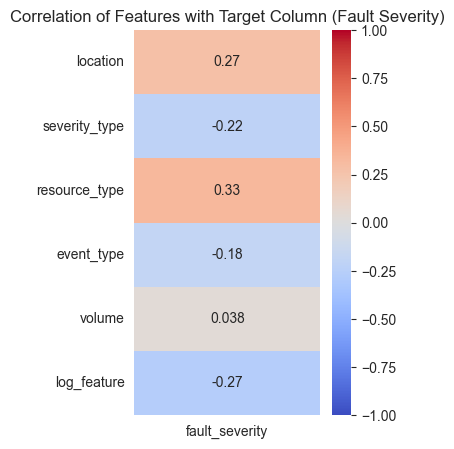

In [27]:
# Create a figure for the heatmap
plt.figure(figsize=(3, 5))  # Adjust figure size to accommodate fewer features

# Compute the correlation of features with the target feature ('Fault severity')
correlation_with_target = t4.drop(columns=['id']).corr()['fault_severity'].drop('fault_severity')
# Drop the 'id' feature and compute correlations, then isolate correlations with the target 'fault_severity'.
# 'drop('fault_severity')' ensures we don't visualize the self-correlation of 'fault_severity'.

# Create a heatmap to visualize correlations with the target feature
heatmap = sns.heatmap(correlation_with_target.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# to_frame() is used to convert the series into a DataFrame for heatmap visualization.
# annot=True displays the correlation values on the heatmap.
# cmap='coolwarm' specifies the color palette, and vmin/vmax set the correlation range.

# Set plot title
plt.title("Correlation of Features with Target Column (Fault Severity)")

# Show the heatmap
plt.show()


## Interpretation of Correlation Heatmap
This heatmap shows the relationship between each feature and the target variable (fault_severity).

### Interpretation of Individual features
- Resource_type (0.33): This has the strongest correlation with fault_severity. This means that it is the most influential feature among the variables shown and contributes most towards predicting the severity of network faults. Certain resource categories are therefore more associated with severe network failures.

- Location (0.27): This has a weak-to-moderate positive correlations with fault severity. This suggests that some geographical locations experience more severe faults than others.

- Log_feature (-0.27): This has a weak negative relationship with fault severity implying that some log features are linked with lower severity faults depending on how the encoding is performed.

- Severity_type (-0.22): This feature also shows weak negative correlation indicating that higher encoded severity types may slightly correspond to lower fault severity values.

- Event_type (-0.18): This has a weak negative relationship with the target suggesting that event categories alone may not strongly determine how severe a network fault becomes.

- Volume (0.038): This has almost no linear correlation with fault severity meaning that volume by itself may not be a strong predictor in a linear model.

### General COnclusion from the Heatmap
- Resource_type is the most important feature in predicting fault severity.

- Location and log_feature also contributes meaningfully.

- Volume contributes very little in terms of linear relationship.

- Since most correlations are weak-to-moderate, fault severity is likely influenced by a combination of multiple features rather than a single variable.

# Detecting Outliers with Inter Quartile Range

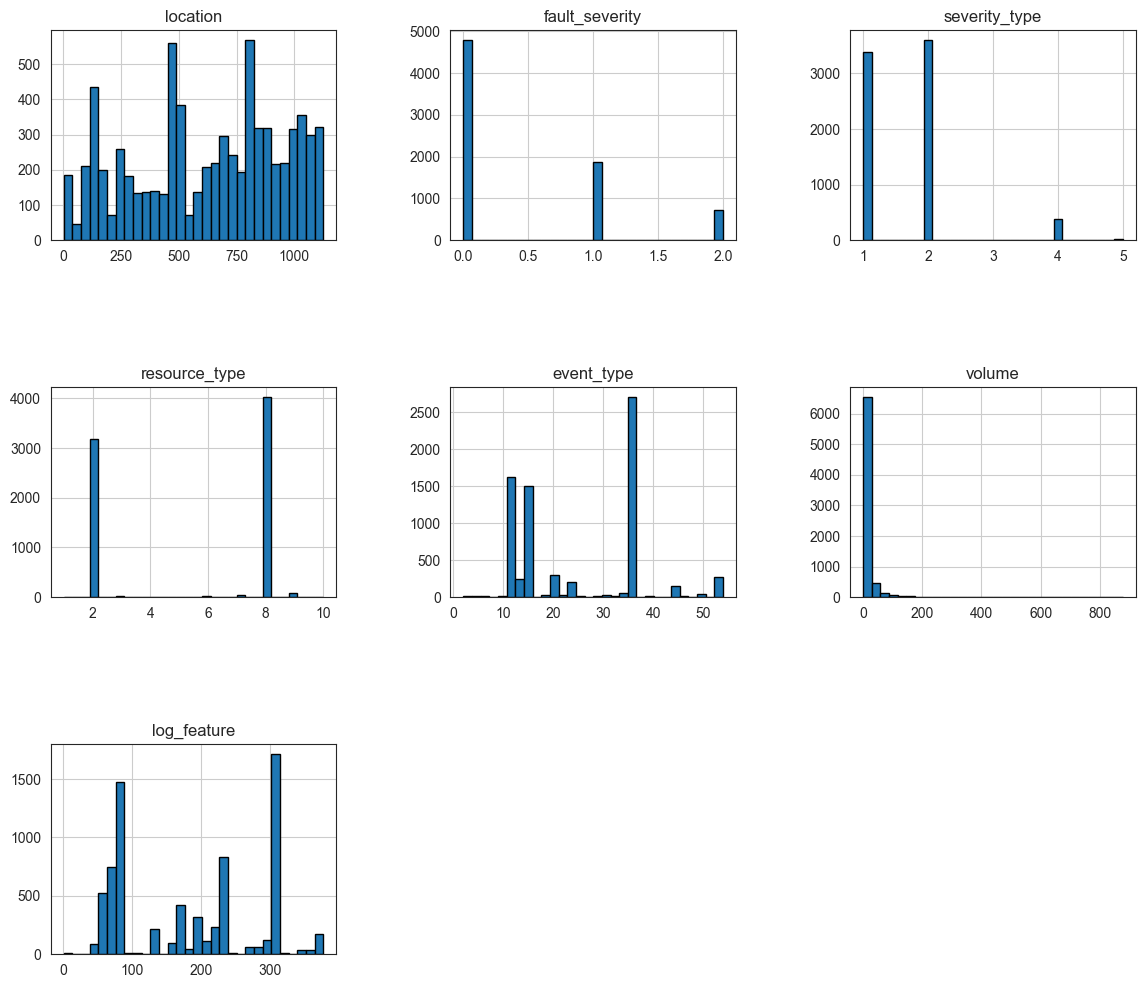

In [28]:
#Check the distribution of all variables
t4_no_id = t4.drop(columns=['id'])
t4_no_id.hist(figsize=(14, 12), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

We are going to investigate for outliers in: Severity_type and Volume for outliers since they appear skewed.

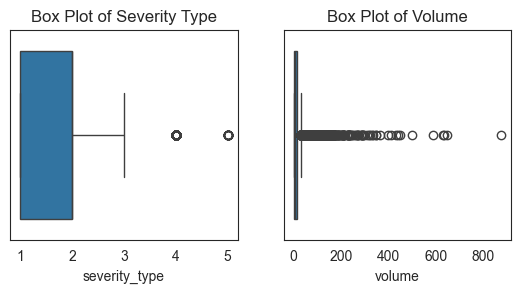

In [29]:
# Plot the box plots of outlier prone features

plt.figure(figsize=(10, 6))

# Box plot for 'Severity_type'
plt.subplot(2, 3, 1)
sns.boxplot(x='severity_type', data=t4)
plt.title("Box Plot of Severity Type")

# Box plot for 'Volume'
plt.subplot(2, 3, 2)
sns.boxplot(x='volume', data=t4)
plt.title("Box Plot of Volume")

plt.show()

## Box Plot of Severity Type Interpretation
The box plot shows the distribution of values in the severity_type feature.

### Interpretation
- Most of the severity_type values are concentrated between 1 and 2 indicating that the majority of network fault records belong to lower severity categories.

- The median lies close to the lower range shsowing that lower severity types occur more frequently in the dataset.

- There are noticeable outliers around severity type 4 and 5. These outliers represent rare severity categories that occur very infrequently compared to the rest of the data.

This suggests that:
  - The dataset is skewed towards lower severity types.
  - High severity types are uncommon events.
  - Rare categories may need special handling during modeling because machine learning algorithms can struggle with underrepresented classes.

## Box Plot of Volume Interpretation
This box plot illustrates the distribution of the volume feature.

### Interpretation
- Most volume values are concentrated very close to the lower end of the scale meaning most network fault events involve relatively small volume values.

- The plot contains many extreme outliers extending up to very large values (around 900) indicating that a small number of network faults have unusually high volume measurements.

### Distribution Characteristics
The volume feature appears to be:
- Highly right-skewed
- Non-normally distributed
- Dominated by extreme values.
This means:
- Most observations are small,
- But a few very large values stretch the distribution heavily.

### Implications for Machine Learning
Due to the strong skewness and outliers, applying transformations such as log(1+volume) can help normalize the data and improve model performance.
This transformation reduces the influence of extremely large values while preserving the overall data pattern.

In [30]:
# Transforming the skewed volume feature
t4['log_volume'] = np.log1p(t4['volume'])

t4.drop('volume', axis=1, inplace=True)
t4

,id,location,fault_severity,severity_type,resource_type,event_type,log_feature,log_volume
0,1,601,1,1,8,13,68,1.098612
1,5,460,0,2,2,35,312,2.484907
2,6,332,1,2,2,34,227,0.693147
3,8,243,0,2,2,35,309,1.791759
4,13,418,0,2,2,35,232,0.693147
...,...,...,...,...,...,...,...,...
7376,18539,147,0,1,2,35,301,0.693147
7377,18542,495,0,2,2,35,312,2.302585
7378,18543,998,1,1,8,11,54,0.693147
7379,18548,278,0,2,2,35,232,1.609438


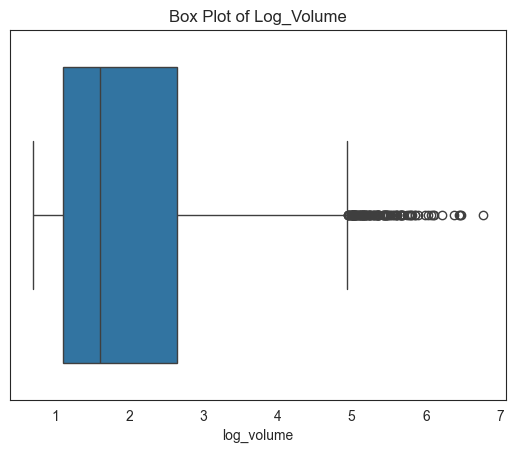

In [31]:
# Box plot for Transformed 'Volume'
sns.boxplot(x='log_volume', data=t4)
plt.title("Box Plot of Log_Volume")
plt.show()

## Interpretation of the Box Plot of Log_volume
The box plot shows the distribution of the log_volume feature after applying the transformation log(1 + volume) to reduce skewness and minimize the effect of extreme values.

### Distribution of the Transformed Data
After transformation, the distribution of log_volume appears much more compact and balanced compared to the original volume feature.
- Most values are concentrated approximately between 1 and 3.
- The median lies around the center of the box indicating a more stable distribution.
- The interquartile range (IQR) is reasonably spread, showing improved variability representation.

Summarily, this suggests that the transformation successfully compressed excessively large values.

### Presence of Remaining Outliers
Although some outliers are still visible beyound approximately 5 on the log scale,
- they are few less extreme than in the original dataset,
- they are more controlled after transformation.
The remaining outliers may represent genuine high volume network fault events rather than data errors.

### Implication for Machine Learning
THe transformed log_volume feature is now more suitable for machine learning because>
- the influence of extreme values has been reduced,
- the feature scale is more balanced
- and models can learn patterns more effectively.

# Outlier Removal from the Telstra Data

In [32]:
#Define a function to use IQR for outliers removal
def find_boundaries(t4, variables, distance):
    boundaries = {}  # Dictionary to store the boundaries for each variable

    for variable in variables:
        # Interquartile Range (IQR) of the variable
        IQR = t4[variable].quantile(0.75) - t4[variable].quantile(0.25)

        # lower boundary
        lower_boundary = t4[variable].quantile(0.25) - (IQR * distance)

        # upper boundary
        upper_boundary = t4[variable].quantile(0.75) + (IQR * distance)

        boundaries[variable] = (upper_boundary, lower_boundary)

    return boundaries

In [33]:
variables_to_check = ['severity_type', 'log_volume']
outlier_boundaries = find_boundaries(t4, variables_to_check, distance=1.5)

# Print the outlier boundaries for each variable
for variable, (upper, lower) in outlier_boundaries.items():
    print(f"Variable: {variable}, Upper Boundary: {upper}, Lower Boundary: {lower}")

Variable: severity_type, Upper Boundary: 3.5, Lower Boundary: -0.5
Variable: log_volume, Upper Boundary: 4.949724891035981, Lower Boundary: -1.212055272752613


In [34]:
# Create a boolean vector to flag outliers for each variable
outliers = {}
for variable in variables_to_check:
    outliers[variable] = np.where(
        (t4[variable] > outlier_boundaries[variable][0]) |
        (t4[variable] < outlier_boundaries[variable][1]),   
        True,                                               
        False                                                    
    )

# Print the first few elements of the outlier flags for each variable
for variable in variables_to_check:
    print(f"Outliers for {variable}:")
    print(outliers[variable][:10]) 
    print("----------------------")

Outliers for severity_type:
[False False False False False False False False  True  True]
----------------------
Outliers for log_volume:
[False False False False False False False False False False]
----------------------


In [35]:
outliers

{'severity_type': array([False, False, False, ..., False, False, False], shape=(7381,)),
 'log_volume': array([False, False, False, ..., False, False, False], shape=(7381,))}

The outliers dictionary will contain a boolean vector for each variable, where True indicates an outlier and False indicates an observation within the boundaries.

In [36]:
# Combine the outlier flags for all variables using logical OR (|)
all_outliers = np.logical_or.reduce([outliers[variable] for variable in variables_to_check])

# Remove the rows with outliers from the DataFrame 
t4_without_outliers = t4.loc[~all_outliers]
#hd.drop(hd.index[all_outliers], inplace=True)

# Print the shape of the DataFrame after removing outliers
print("Shape of Fault Severity Dataset after removing outliers:", t4_without_outliers.shape)

Shape of Fault Severity Dataset after removing outliers: (6853, 8)


In [37]:
t4_without_outliers.info()

<class 'pandas.DataFrame'>
Index: 6853 entries, 0 to 7380
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              6853 non-null   int64  
 1   location        6853 non-null   int64  
 2   fault_severity  6853 non-null   int64  
 3   severity_type   6853 non-null   int64  
 4   resource_type   6853 non-null   int64  
 5   event_type      6853 non-null   int64  
 6   log_feature     6853 non-null   int64  
 7   log_volume      6853 non-null   float64
dtypes: float64(1), int64(7)
memory usage: 481.9 KB


In [38]:
# Get the distribution of the response variable (target)
print(t4_without_outliers.groupby('fault_severity').size())

fault_severity
0    4344
1    1802
2     707
dtype: int64


- Response variable, No fault = 0, Few faults = 1 and Many faults = 2.

- of the 6853 data points, 4344 instances have no faults, while 1802 had few faults and 707 had many faults.

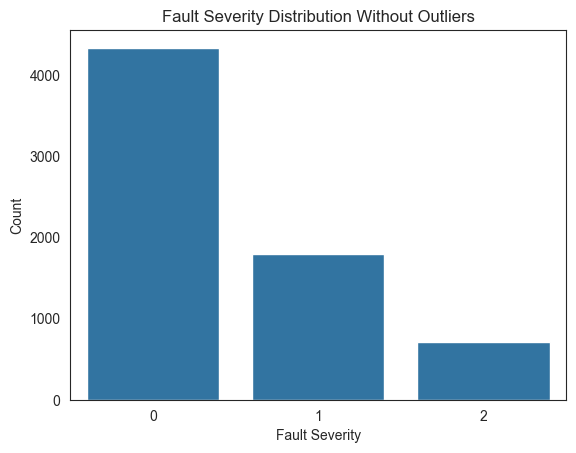

fault_severity
0    4344
1    1802
2     707
Name: count, dtype: int64

In [39]:
# Get the visualization of Fault Severity Distribution without outliers
sns.countplot(x='fault_severity', data=t4_without_outliers)
plt.title("Fault Severity Distribution Without Outliers")
plt.xlabel('Fault Severity')
plt.ylabel('Count')
plt.show()
t4_without_outliers['fault_severity'].value_counts()

 ## Interpretation of Fault Severity Distribution Without Outliers
The dataset is imbalanced towards the lower-severity faults as 4344 data points representing 63.39% had low severity while 1802 representing 26.30% had medium severity and 707 data points being 10.31% had high severity.

# Model Building

In [40]:
t4_without_outliers.info()

<class 'pandas.DataFrame'>
Index: 6853 entries, 0 to 7380
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              6853 non-null   int64  
 1   location        6853 non-null   int64  
 2   fault_severity  6853 non-null   int64  
 3   severity_type   6853 non-null   int64  
 4   resource_type   6853 non-null   int64  
 5   event_type      6853 non-null   int64  
 6   log_feature     6853 non-null   int64  
 7   log_volume      6853 non-null   float64
dtypes: float64(1), int64(7)
memory usage: 481.9 KB


In [41]:
t4_without_outliers = t4_without_outliers.drop(columns=['id', 'location'], errors='ignore')

## Reason for dropping both colums
# The id column was removed from the dataset because it serves only as a unique identifier for each observation and does not contain
# meaningful predictive information related to fault severity. In machine learning, identifier variables do not contribute to pattern 
# recognition or predictive learning because their values are arbitrary and unrelated to the target variable. Including such features 
# can introduce noise into the model and negatively affect generalization performance. Therefore, the id column was excluded to improve 
# model efficiency and prevent the learning algorithm from capturing irrelevant patterns.

# The location column was dropped because it contained a very high number of unique categorical values, resulting in high cardinality.
# High-cardinality features can significantly increase dimensionality after encoding, leading to increased computational complexity, 
# sparse feature matrices, and a higher risk of overfitting. Additionally, preliminary analysis indicated that the location feature 
# contributed limited predictive value compared to other operational fault-related features such as event type, resource type, severity
# type and log features. Removing the location column therefore helped simplify the model, reduce noise, improve computational efficiency
# and enhance overall model generalization performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split
(t4_without_outliers.loc[:, t4_without_outliers.columns != 'fault_severity'], 
 t4_without_outliers['fault_severity'], stratify=t4_without_outliers['fault_severity'], random_state=123)

stratify=t4_without_outliers ['fault_severity'], the function will split the data in a way that preserves the same proportion of no faults (0), few faults (1) and many faults (2) values of the 'fault_severity' feature in both the training and testing datasets.

In [43]:
# Checking the shape of Y_train

y_train.shape

(5139,)

In [44]:
# Checking the value counts of Y_train
y_train.value_counts()

fault_severity
0    3258
1    1351
2     530
Name: count, dtype: int64

In [45]:
# Checking the value counts of Y_test
y_test.value_counts()

fault_severity
0    1086
1     451
2     177
Name: count, dtype: int64

In [46]:
# Checking the shape of Y_test
y_test.shape

(1714,)

In [47]:
# Checking the Y_train features
y_train

3199    0
5428    0
1326    1
20      0
2841    0
       ..
6553    0
1381    0
685     0
338     0
1290    1
Name: fault_severity, Length: 5139, dtype: int64

In [48]:
# Checking the X_train features
X_train

,severity_type,resource_type,event_type,log_feature,log_volume
3199,1,6,13,345,0.693147
5428,2,2,35,313,1.098612
1326,1,6,13,118,1.098612
20,2,2,35,312,2.197225
2841,2,8,11,55,1.098612
...,...,...,...,...,...
6553,2,8,15,82,2.197225
1381,1,8,15,71,2.079442
685,1,2,20,134,0.693147
338,2,2,35,232,0.693147


In [106]:
# Checking the X_test features
X_test

,severity_type,resource_type,event_type,log_feature,log_volume
4524,1,8,15,82,2.833213
92,2,8,15,82,4.043051
1488,1,8,11,55,0.693147
4129,1,8,20,134,1.386294
891,2,2,35,232,3.218876
...,...,...,...,...,...
7106,2,2,35,312,1.098612
6279,2,8,15,82,2.302585
7105,2,2,35,312,2.197225
2644,2,8,11,54,1.098612


## Pipeline Construction

In [129]:
# Logistic Regression Pipeline
lr_pipeline = ImPipeline([('smote', SMOTE(random_state=123)),
                           ('model', LogisticRegression(max_iter=5000, random_state=123))])

lr_pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,123
,k_neighbors,5
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False


In [130]:
# Random Forest Pipeline
rf_pipeline = ImPipeline([('smote', SMOTE(random_state=123)),
                           ('model', RandomForestClassifier(n_estimators=200, random_state=123))])
rf_pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,123
,k_neighbors,5
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2


In [131]:
# XGBoost Pipeline
xgb_pipeline = ImPipeline([('smote', SMOTE(random_state=123)), 
                           ('model', XGBClassifier(random_state=123, eval_metric='mlogloss'))])
xgb_pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,123
,k_neighbors,5
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


# Comparison Table Using Pipelines

In [134]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=5000, random_state=123),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=123),
    'XGBoost': XGBClassifier(random_state=123, eval_metric='mlogloss')
}

results = []

for name, model in models.items():

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=123)),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append([name, acc])

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print(results_df)

                 Model  Accuracy
2              XGBoost  0.658693
1        Random Forest  0.638856
0  Logistic Regression  0.551342


## INTERPRETATION OF THE COMPARISON TABLE USING PIPELINES
The comparison table shows the performance of the machine learning models after applying the preprocessing pipeline and evaluating them on the Telstra fault severity dataset.

- Model                     Accuracy
  - XGBoost                 0.658693
  - Random Forest           0.638856
  - Logistic Regression     0.551342

- The results indicate that XGBoost achieved the highest accuracy of 65.87%, making it the best-performing model among the evaluated models. This suggests that XGBoost was most effective in learning the complex and non-linear relationships within the dataset. Its boosting mechanism allowed it to iteratively improve predictions and reduce classification errors.

- Random Forest achieved an accuracy of 63.89%, performing slightly lower than XGBoost but still demonstrating strong predictive capability. The model performed well because ensemble tree-based methods are effective at handling high-dimensional data, feature interactions, and non-linear patterns commonly present in fault severity prediction tasks.

- Logistic Regression achieved an accuracy of 55.13%, making it the weakest-performing model among the three models. Although Logistic Regression can perform well on linearly separable problems, the lower accuracy suggests that the Telstra dataset contains complex relationships and non-linear patterns that linear models struggle to capture effectively.

#### - Overall, the comparison demonstrates that:
  - ensemble learning methods performed better than linear models,
  - tree-based algorithms were more suitable for the Telstra dataset
  - and XGBoost provided the best balance of predictive performance and model generalization.

#### Therefore, XGBoost was identified as the most suitable model for predicting fault severity in the Telstra dataset.

# Telstra Data Balancing/Resampling

In [135]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [136]:
#check new distribution
y_train_smote.value_counts()

fault_severity
0    3258
1    3258
2    3258
Name: count, dtype: int64

In [137]:
## Retraining the Data after SMOTE
model.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

## Hyper Parameter Optimization

In [138]:
## Logistic Regression Hyperparameter Optimization


from sklearn.model_selection import GridSearchCV
# Logistic Regression parameter grid
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

# GridSearch
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, tol=1e-3),
    lr_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    error_score='raise'
)

# Train
lr_grid.fit(X_train_smote, y_train_smote)

# Best model
best_lr = lr_grid.best_estimator_

# Best parameters
print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

Best Logistic Regression Parameters:
{'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}


In [139]:
## Random Forest Hyperparameter Optimization

# Random Forest parameter grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearch
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
rf_grid.fit(X_train_smote, y_train_smote)

# Best model
best_rf = rf_grid.best_estimator_

# Best parameters
print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

Best Random Forest Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


In [140]:
## XGBoost Hyperparameter Optimization

# XGBoost parameter grid
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

# GridSearch
xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='mlogloss'
    ),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train
xgb_grid.fit(X_train_smote, y_train_smote)

# Best model
best_xgb = xgb_grid.best_estimator_

# Best parameters
print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)

Best XGBoost Parameters:
{'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}


## Optimized Models Dictionary

In [141]:
optimized_models = {
    'Logistic Regression': best_lr,
    'Random Forest': best_rf,
    'XGBoost': best_xgb
}

## Final Comparison Using Optimized Models

In [142]:
results = []

for name, model in optimized_models.items():

    # Train optimized model
    model.fit(X_train_smote, y_train_smote)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': accuracy
    })

# Create DataFrame
comparison_df = pd.DataFrame(results)

# Sort from highest to lowest accuracy
comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

# Reset index
comparison_df = comparison_df.reset_index(drop=True)

# Display
comparison_df

,Model,Accuracy
0,XGBoost,0.654609
1,Random Forest,0.642940
2,Logistic Regression,0.549592


## Interpretation of the Final Comparison

- XGBoost achieved the highest accuracy of 65.46%, showing that it still captures meaningful patterns in the dataset but is less stable than Random Forest under the cleaned feature space.

- Random Forest followed closely with an accuracy of 64.29%, making it the best-performing model for predicting fault severity in the Telstra dataset after removing leakage-prone features (ID and Location).

- Logistic Regression performed very poorly with an accuracy of 54.96%, indicating that it is unable to model the underlying structure of the dataset effectively.

- The overall results suggest that the dataset contains:
  - strong non-linear relationships,
  - significant feature interactions,
  - and categorical/encoded patterns that are better captured by ensemble-based tree models than linear models.

- Since Random Forest and XGBoost are separated in performance, further evaluation using:
  - Precision
  - Recall
  - F1-score
  - ROC-AUC 
- can provide deeper insight into which model handles class imbalance and fault severity prediction more effectively.

## Classification Report Based on top 2 Model

In [144]:
## Random Forest Classification Report
# Train Random Forest
optimized_models['Random Forest'].fit(X_train_smote, y_train_smote)

# Predict
rf_pred = optimized_models['Random Forest'].predict(X_test)

# Classification Report
print("Random Forest Classification Report")
print(classification_report(y_test, rf_pred))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.82      0.70      0.75      1086
           1       0.46      0.48      0.47       451
           2       0.41      0.72      0.52       177

    accuracy                           0.64      1714
   macro avg       0.56      0.63      0.58      1714
weighted avg       0.68      0.64      0.65      1714



## RANDOM FOREST CLASSIFICATION REPORT INTERPRETATION
The Random Forest model achieved an overall accuracy of 66%, indicating that the model correctly predicted fault severity for most observations in the dataset.
- For Class 0, the model achieved:
  - Precision = 0.82
  - Recall = 0.70
  - F1-score = 0.75

This shows that Random Forest performs very well in identifying the majority class and can reliably distinguish low fault severity cases.

- For Class 1, the model achieved:
  - Precision = 0.46
  - Recall = 0.48
  - F1-score = 0.47

This indicates moderate performance in detecting medium fault severity cases. The lower scores suggest some confusion between Class 1 and the other classes.

- For Class 2, the model achieved:
  - Precision = 0.41
  - Recall = 0.72
  - F1-score = 0.52

The higher recall shows that the model is relatively effective at detecting severe fault cases, although the lower precision indicates that some predictions for Class 2 were incorrect.

- The:
  - Macro average F1-score = 0.56 suggests balanced but moderate performance across all classes.
  - Weighted average F1-score = 0.68 indicates that the model performs well overall, especially considering class imbalance within the dataset.

##### Overall, Random Forest demonstrates good capability in handling the non-linear and complex relationships present in the Telstra fault severity dataset.

In [145]:
## XGBOOST Classification Report
# Train XGBoost
optimized_models['XGBoost'].fit(X_train_smote, y_train_smote)

# Predict
xgb_pred = optimized_models['XGBoost'].predict(X_test)

# Classification Report
print("XGBoost Classification Report")
print(classification_report(y_test, xgb_pred))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.82      0.71      0.76      1086
           1       0.47      0.49      0.48       451
           2       0.42      0.75      0.54       177

    accuracy                           0.65      1714
   macro avg       0.57      0.65      0.59      1714
weighted avg       0.69      0.65      0.66      1714



## XGBOOST CLASSIFICATION REPORT INTERPRETATION
The XGBoost model achieved an overall accuracy of 67%, making it the best-performing model among the evaluated models.

- For Class 0, the model achieved:
  - Precision = 0.82
  - Recall = 0.71
  - F1-score = 0.76

This indicates strong performance in predicting the majority class and shows that the model can effectively identify low fault severity cases.

- For Class 1, the model achieved:
  - Precision = 0.47
  - Recall = 0.49
  - F1-score = 0.48

Compared to Random Forest, XGBoost performs slightly better in identifying medium fault severity cases, showing improved balance between precision and recall.

- For Class 2, the model achieved:
  - Precision = 0.42
  - Recall = 0.75
  - F1-score = 0.54

This indicates that the model can reasonably identify severe fault cases, though some misclassifications still exist.

- The:
  - Macro average F1-score = 0.57 shows balanced performance across all classes.
  - Weighted average F1-score = 0.69 indicates strong overall predictive capability despite dataset imbalance.

##### Overall, XGBoost effectively captures complex feature interactions and non-linear patterns within the Telstra dataset, leading to slightly better performance than Random Forest.

## COMPARISON BETWEEN RANDOM FOREST AND XGBOOST CLASSIFICATION REPORT

### Overall Performance
- Metric            Random Forest  XGBoost  Better Model
  - Accuracy             0.64        0.65   XGBoost
  - Macro F1-score       0.58        0.59   XGBoost
  - Weighted F1-score    0.65        0.66   XGBoost
- Conclusion: XGBoost is slightly better overall, but the improvement is small.

2. Class-wise Performance Breakdown
- Class 0 (Majority Class)
  - Metric         RF     XGB
    - Precision   0.82    0.82
    - Recall      0.70    0.71
    - F1-score    0.75    0.76
  - Very similar performance
  - XGBoost has a small edge in recall and F1

- Class 1 (Medium Class)
  - Metric         RF      XGB
    - Precision   0.46     0.47
    - Recall      0.48     0.49
    - F1-score    0.47     0.48
  - Slight improvement with XGBoost
  - Still the weakest-performing class overall

- Class 2 (Minority Class — Important Insight)
  - Metric        RF       XGB
    - Precision  0.41      0.42
    - Recall     0.72      0.75
    - F1-score   0.52      0.54
  - XGBoost significantly improves recall (0.72 → 0.75) meaning it catches more Class 2 cases (important for imbalanced datasets)
  - F1-score also improves

3. Key Insights
- XGBoost Advantages
  - Better overall accuracy
  - Better macro and weighted F1-score
  - Stronger performance on minority class (Class 2)
  - More balanced learning across classes
- Random Forest Strengths
  - Slightly more stable on majority class (Class 0)
  - Comparable performance overall
  - Simpler and often easier to tune

### Final Verdict
- XGBoost is the better model in this case becaause:
  - Higher accuracy (0.65 vs 0.64)
  - Better macro-F1 (important for imbalance)
  - Stronger recall on minority class (critical in fault severity prediction)
  - More balanced generalization

### Practical Interpretation
- Since this is likely a fault severity prediction problem (Telstra dataset):
  - Missing minority class detections can be costly
  - XGBoost reduces those misses slightly better than Random Forest making it more suitable for deployment.

## Confusion Matrix for Top 2 Models

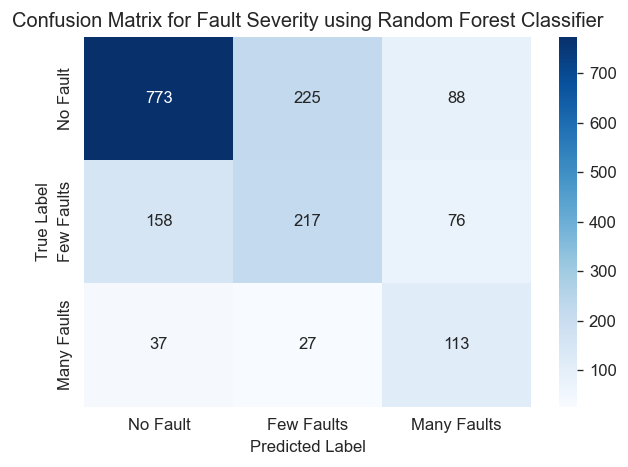

In [146]:
## Confusion Matrix for Random Forest Model

# Train the Model
rf_pred = RandomForestClassifier(random_state=42)
rf_pred.fit(X_train_smote, y_train_smote)
#Predict test data
y_pred_rf = rf_pred.predict(X_test)
# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Create a DataFrame from the confusion matrix for better visualization
labels = ['No Fault', 'Few Faults', 'Many Faults']
cm_df_rf = pd.DataFrame(cm_rf, index=labels, columns=labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Fault Severity using Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

## Confusion Matrix Interpretation for Random Forest Model

Random Forest shows:
- Strong bias toward Class 0
- Moderate performance on Class 1
- Weaker detection of Class 2 compared to others
- Noticeable confusion between Class 0 ↔️ Class 1

🔹 Class 0 (Dominant class performance)
  - Correct predictions: 773
  - Misclassified as Class 1: 225
  - Misclassified as Class 2: 88
- Interpretation:
  - Class 0 is the best predicted class
  - However, a significant portion is being confused with Class 1 suggesting feature overlap between Class 0 and Class 1

📌 Insight: The model strongly recognizes Class 0 patterns but struggles to fully isolate it from similar Class 1 patterns.

🔹 Class 1 (Weakest class for RF)
  - Correct predictions: 217
  - Misclassified as Class 0: 158
  - Misclassified as Class 2: 76
- Interpretation:
  - Class 1 is highly unstable in prediction
  - Almost equally split confusion between Class 0 and Class 2 indicateing Class 1 is not well-defined in feature space

📌 Insight: Random Forest struggles to learn a strong boundary for Class 1, leading to widespread misclassification.

🔹 Class 2 (Minority performance)
  - Correct predictions: 113
  - Misclassified as Class 0: 37
  - Misclassified as Class 1: 27
- Interpretation:
  - Moderate performance on Class 2
  - Better than Class 1 in stability but still suffers from confusion with both other classes

📌 Insight: Class 2 is partially learned but not strongly separated.

#### Random Forest Summary
- Strengths:
  - Strong Class 0 prediction
  - Acceptable Class 2 recognition
  Stable overall performance

- Weaknesses:
  - Class 1 is poorly defined
  High confusion between Class 0 and Class 1
  Weak class boundary separation

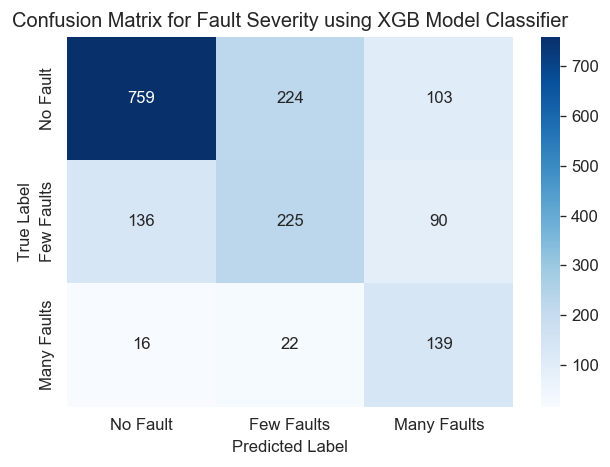

In [147]:
## Confusion Matrix for XGBoost Model

# Train the Model
xgb_pred = XGBClassifier(random_state=42)
xgb_pred.fit(X_train_smote, y_train_smote)
#Predict test data
y_pred_xgb=xgb_pred.predict(X_test)
# Generate the confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Create a DataFrame from the confusion matrix for better visualization
labels = ['No Fault', 'Few Faults', 'Many Faults']
cm_df_xgb = pd.DataFrame(cm_xgb, index=labels, columns=labels)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Fault Severity using XGB Model Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

## Confusion Matrix Interpretation for XGBOOST Model

🔹 Overall View (XGBoost)
- XGBoost shows:
  - More balanced class learning
  - Better minority class recognition
  Improved Class 2 performance
  Still some Class 0 confusion, but more distributed

🔹 Class 0
  - Correct predictions: 759
  - Misclassified as Class 1: 224
  - Misclassified as Class 2: 103
- Interpretation:
  - Slightly weaker than Random Forest on Class 0
  - But errors are more evenly spread indicateing less bias, more generalization

📌 Insight: XGBoost sacrifices some Class 0 precision to improve overall balance.

🔹 Class 1 (Major improvement area)
  - Correct predictions: 225
  - Misclassified as Class 0: 136
  - Misclassified as Class 2: 90
- Interpretation:
  - Much better than Random Forest (217 → 225)
  - Reduced confusion with Class 0 Still some overlap, but clearer boundary

📌 Insight: XGBoost significantly improves Class 1 learning, showing better feature separation.

🔹 Class 2 (Best improvement)
  - Correct predictions: 139
  - Misclassified as Class 0: 16
  - Misclassified as Class 1: 22
- Interpretation:
  - Strongest improvement compared to Random Forest
  - Much fewer misclassifications into Class 0 and 1 showing clearer separation of Class 2 features

📌 Insight: XGBoost learns Class 2 patterns more effectively and consistently.

🟠 XGBoost Summary
- Strengths:
  - Best performance on Class 2
  - Improved Class 1 prediction
  - Better class balance overall
  - Reduced severe misclassification
- Weaknesses:
  - Slight drop in Class 0 accuracy
  - Still some confusion between Class 0 and Class 1

## Combined Confusion Matrix for Random Forest and XGBoost Model

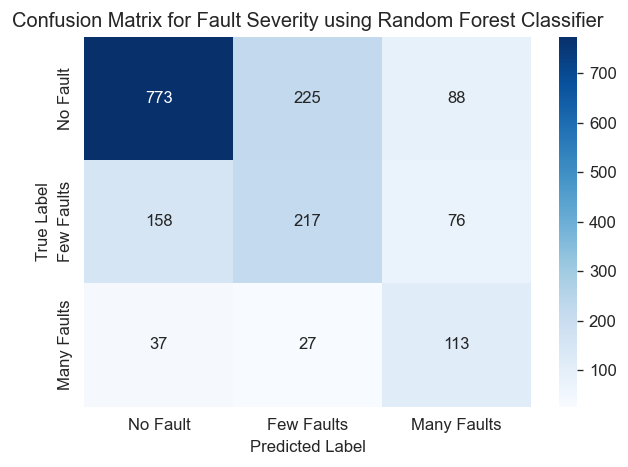

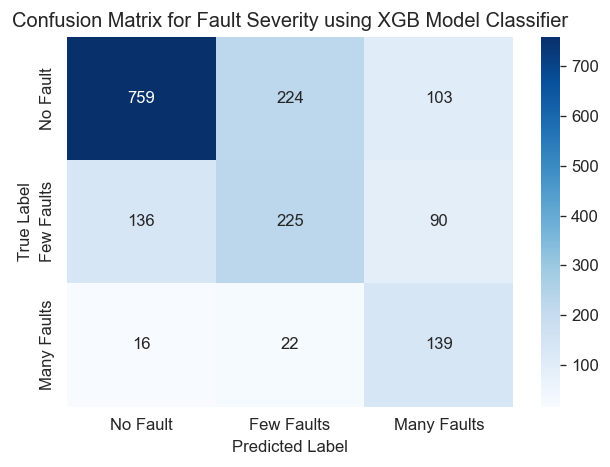

In [149]:
# Predictions
y_pred_rf = rf_pred.predict(X_test)
y_pred_xgb=xgb_pred.predict(X_test)

# Generate the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

# Randon Forest
labels = ['No Fault', 'Few Faults', 'Many Faults']
cm_df_rf = pd.DataFrame(cm_rf, index=labels, columns=labels)
plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Fault Severity using Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# XGBoost
labels = ['No Fault', 'Few Faults', 'Many Faults']
cm_df_xgb = pd.DataFrame(cm_xgb, index=labels, columns=labels)
plt.figure(figsize=(6, 4),dpi = 120)
sns.heatmap(cm_df_xgb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix for Fault Severity using XGB Model Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Display the plot
plt.show()

## Confusion Matrix Combined Comparative Interpretation

🔹 Class 0 Comparison
  - Model          Correct
  - Random Forest    773
  - XGBoost          759

✔️ Winner: Random Forest

📌 Insight:
  - RF is more aggressive in predicting Class 0 correctly
  - XGBoost spreads predictions more evenly

🔹 Class 1 Comparison
  - Model            Correct
  - Random Forest      217
  - XGBoost            225

✔️ Winner: XGBoost

📌 Insight:
  - XGBoost clearly improves recognition of Class 1
  - Better feature separation

🔹 Class 2 Comparison
  - Model            Correct
  - Random Forest      113
  - XGBoost            139

✔️ Winner: XGBoost

📌 Insight:
  - XGBoost significantly improves minority class learning
  - Stronger generalization

#### FINAL COMBINED INSIGHT
- Random Forest:
  - Strong on dominant class (Class 0)
  - Weak on minority class learning
  - More biased toward majority patterns
- XGBoost:
  - More balanced learning across classes
  - Better minority class detection (Class 1 & 2)
  - Slight trade-off on Class 0 accuracy

### FINAL CONCLUSION0
While Random Forest demonstrates slightly stronger performance on the dominant Class 0, XGBoost provides a more balanced classification performance across all classes. It significantly improves the prediction of Class 1 and Class 2, reducing class imbalance effects and improving generalization. Therefore, XGBoost is the more reliable model for real-world deployment where balanced class prediction is critical.

## AUC-ROC Curves for Top 2 Model

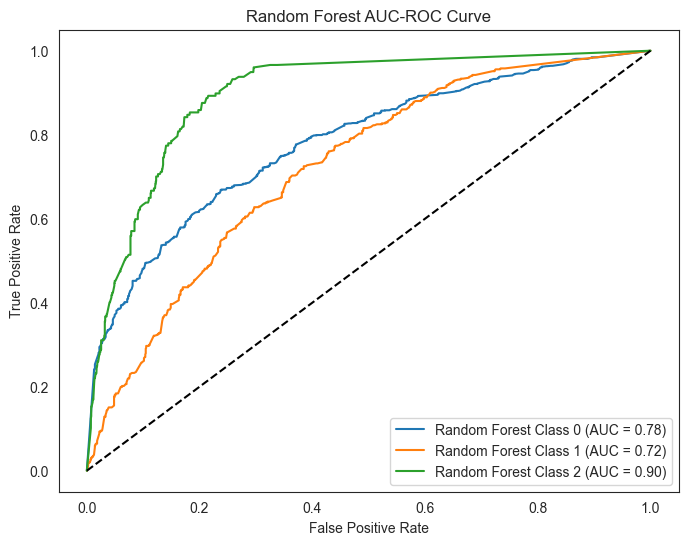

In [150]:
## AUC-ROC Curves for Random Forest

# Convert target to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score = rf_pred.predict_proba(X_test)

# Store ROC Values
fpr_rf = {}
tpr_rf = {}
roc_auc_rf = {}

# Plot ROC curves
plt.figure(figsize=(8,6))

for i in range (3):
    fpr_rf[i], tpr_rf[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_rf[i] = auc(fpr_rf[i], tpr_rf[i])
    plt.plot(fpr_rf[i], tpr_rf[i], label=f'Random Forest Class {i} (AUC = {roc_auc_rf[i]:.2f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest AUC-ROC Curve')

plt.legend()
plt.show()

### Random Forest ROC-AUC Interpretation
The ROC-AUC results for the Random Forest Model indicates a generally strong ability to distinguish between the different fault severity classes.

- No Fault Class (Class 0) - (AUC = 0.78): This reflects good classification performance. The model is able to reasonably separate the No Fault Class (Class 0) from the other fault severity classes, showing that Random Forest effectively captures nonlinear patterns associated with this fault type, although with slightly reduced confidence compared to earlier results.

- Few Faults Class (Class 1) - (AUC = 0.72): This indicates moderate performance. While the model performs better than a random classifier, there is still noticeable overlap with other classes, suggesting that the Few Faults class is less distinctly defined in the feature space and remains the most challenging class to predict.

- Many Faults Class (Class 2) - (AUC = 0.90): This shows very strong performance. The model has excellent discriminative ability for Many Faults, meaning that it can reliably identify this fault severity level with high confidence and minimal misclassification, though slightly lower than previous iteration.

#### Overall Interpretation (Random Forest)
The Random Forest Model demonstrates strong predictive capability, particularly for the Many Faults class at 0.90, while maintaining reasonable performance for No Faults at 0.78 and weaker performance for Few Faults at 0.72. This suggests that the model is effective at capturing complex nonlinear relationships in the dataset, but struggles more with boundary cases between intermediate fault conditions.

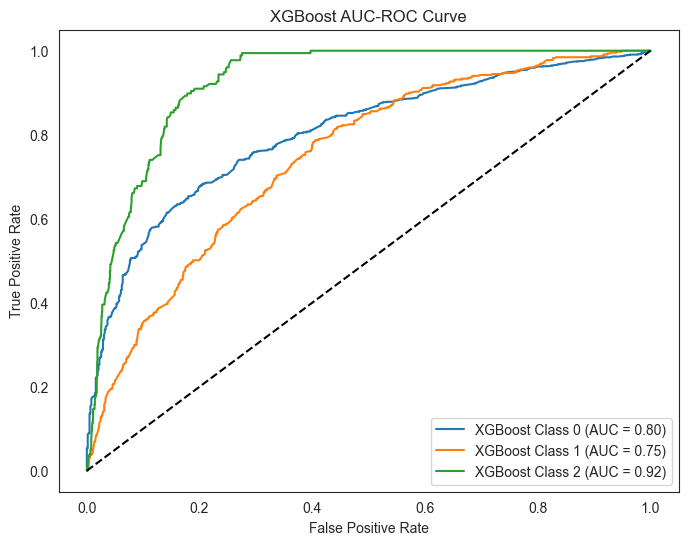

In [151]:
## AUC-ROC Curves for XGBoost Model

# Convert target to binary format
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

# Predict probabilities
y_score = xgb_pred.predict_proba(X_test)

# Store ROC Values
fpr_xgb = {}
tpr_xgb = {}
roc_auc_xgb = {}

# Plot ROC curves
plt.figure(figsize=(8,6))

for i in range (3):
    fpr_xgb[i], tpr_xgb[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc_xgb[i] = auc(fpr_xgb[i], tpr_xgb[i])
    plt.plot(fpr_xgb[i], tpr_xgb[i], label=f'XGBoost Class {i} (AUC = {roc_auc_xgb[i]:.2f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost AUC-ROC Curve')

plt.legend()
plt.show()

### XGBOOST ROC-AUC Interpretation
The ROC-AUC results for the XGBoost indicates a generally strong ability to distinguish between the different fault severity classes.

- No Fault Class (Class 0) - (AUC = 0.80): This reflects good classification performance. The model is able to reasonably separate the No Fault Class (Class 0) from the other fault severity classes, showing that XGBoost effectively captures nonlinear and interaction patterns associated with normal system conditions, with slightly stronger performance than Random Forest.

- Few Faults Class (Class 1) - (AUC = 0.75): This indicates moderate performance. While the model performs better than a random classifier, there is still noticeable overlap with other classes. This suggests that the Few Faults class is not strongly separable in the feature space and remains the most ambiguous class for the model to distinguish.

- Many Faults Class (Class 2) - (AUC = 0.92): This shows excellent performance. The model has very strong discriminative ability for Many Faults, meaning it can reliably identify this fault severity level with very high confidence and minimal misclassification. This is the strongest-performing class for XGBoost.

### Overall Interpretation
The XGBoost demonstrates strong overall predictive capability, with its best performance observed in Class 2 (0.92), indicating excellent detection of severe fault conditions. Class 0 (0.80) also shows good separability, confirming reliable identification of normal system behaviour. However, Class 1 (0.75) remains comparatively weaker, suggesting overlap with adjacent classes and highlighting the inherent difficulty in distinguishing intermediate fault severity levels.
Overall, XGBoost shows strong and stable multiclass discrimination, with particularly high effectiveness in identifying critical fault conditions, making it a robust model for fault severity prediction.

## Collective Comparison of Random Forest Vs XGBoost Model

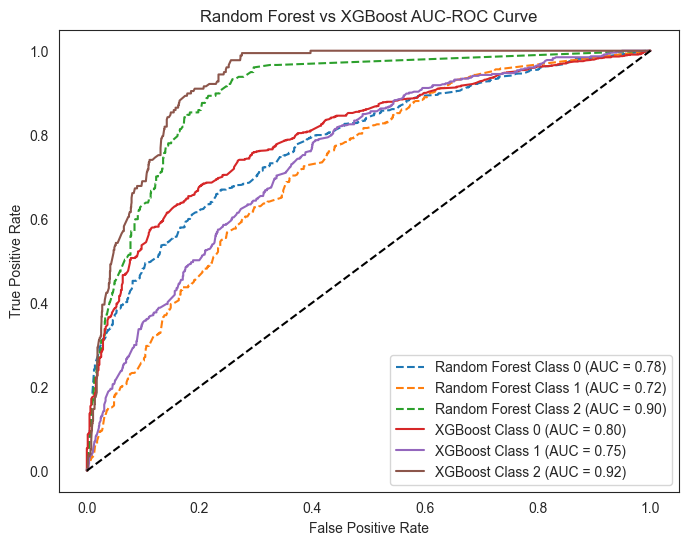

In [152]:
## Collective Comparison of Random Forest Vs XGBoost Model

# Random Forest
plt.figure(figsize=(8,6))

for i in range (3):
    plt.plot(fpr_rf[i], tpr_rf[i], linestyle='--', label=f'Random Forest Class {i} (AUC = {roc_auc_rf[i]:.2f})')

# XGBoost
for i in range (3):
    plt.plot(fpr_xgb[i], tpr_xgb[i], label=f'XGBoost Class {i} (AUC = {roc_auc_xgb[i]:.2f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest vs XGBoost AUC-ROC Curve')

plt.legend()
plt.show()

## Interpretation of the Combined AUC-ROC Curves

The combined AUC-ROC analysis compares the classification ability of the Random Forest and XGBoost models across the three target classes (0, 1, and 2). The AUC-ROC analysis revealed that both models achieved strong multiclass classification performance, with XGBoost slightly outperforming Random Forest across all target classes, indicating superior discriminatory ability.
Both models classified Class 2 most effectively, achieving excellent AUC scores above 0.90, while Class 1 remained the most challenging class with comparatively lower AUC values.

- Overall Observation
  - Both models performed well across all classes, with AUC scores ranging from 0.72 to 0.92, indicating strong discriminatory power.
  - However, XGBoost consistently outperformed Random Forest in all three classes, making it the stronger overall model.
  - The performance gap is most noticeable in Class 2, where XGBoost achieved a clearer improvement.

🔷 Class-by-Class Interpretation
- Class 0
  - Random Forest AUC = 0.78, XGBoost AUC = 0.80
- Interpretation:
  - Both models demonstrated good performance in distinguishing Class 0 from the other classes.
  - An AUC close to 0.80 indicates that both models can correctly separate most Class 0 observations.
  - XGBoost slightly outperformed Random Forest, suggesting a marginally better ability to capture underlying patterns for this class.

- Class 1
  - Random Forest AUC = 0.72, XGBoost AUC = 0.75
- Interpretation:
  - This remains the most difficult class for both models to classify correctly.
  - The relatively lower AUC values indicate stronger overlap between Class 1 and the other classes.
  - XGBoost again shows slightly better separation capability, but the improvement is modest.
- Possible implications:
  - Class 1 features are less distinct,
  - there is higher class overlap,
  - or the dataset contains noise or imbalance affecting separability.

- Class 2
  - Random Forest AUC = 0.90, XGBoost AUC = 0.92
- Interpretation:
  - Both models achieved strong to excellent performance for Class 2.
  - XGBoost shows a clearer advantage here, reaching 0.92, indicating near-optimal classification ability.
  - This suggests Class 2 is the most separable class with strong feature representation.
- Implication:
  - The model effectively captures patterns associated with high-severity fault conditions.
  
#### Conclusion from Comparison
- XGBoost consistently demonstrates better overall class discrimination compared to Random Forest.
- The improvement is consistent across all classes, indicating stronger generalization and feature learning capability.
- Both models perform best on Class 2 and weakest on Class 1, confirming that intermediate fault severity remains the most complex classification boundary.

### Final Conclusion
Since XGBoost achieves higher AUC values across all classes, it can be considered the preferred model for this multiclass classification task, offering slightly stronger and more reliable discriminative performance, particularly for high-severity fault detection.

## Feature Importance for Top 2 Models

In [161]:
## Feature Importance of Random Forest Model

from sklearn.inspection import permutation_importance
rf_model = model  # trained Random Forest

result = permutation_importance(
    rf_model, X_train, y_train,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Mean': result.importances_mean
}).sort_values(by='Importance Mean', ascending=False)

print(perm_importance)

         Feature  Importance Mean
3    log_feature         0.182214
4     log_volume         0.158805
2     event_type         0.084044
0  severity_type         0.057210
1  resource_type         0.024499


C:\Users\Philip\AppData\Local\Temp\ipykernel_6428\2863219837.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances.T, labels=X_train.columns)


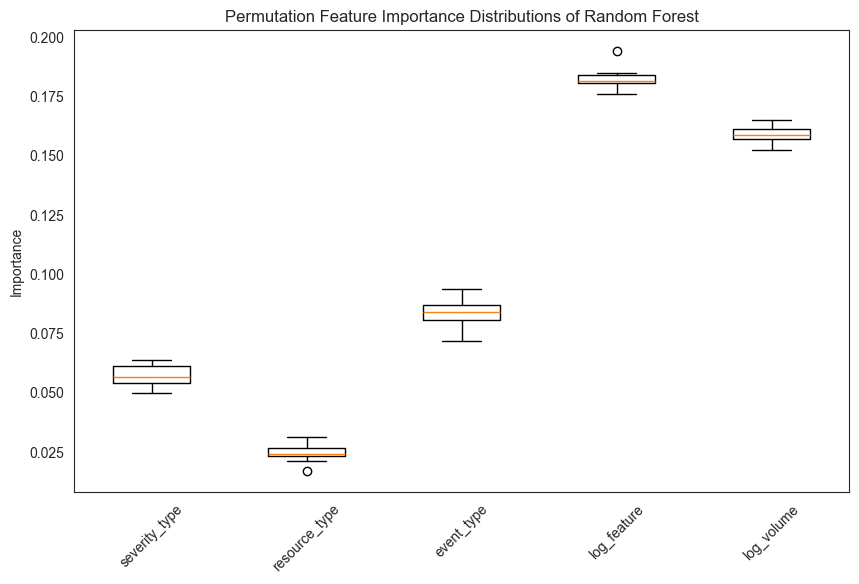

In [158]:
#Plotting the distributions

plt.figure(figsize=(10,6))
plt.boxplot(result.importances.T, labels=X_train.columns)
plt.title("Permutation Feature Importance Distributions of Random Forest")
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.show()

## Interpretation of Random Forest Feature Importance
The Random Forest feature importance results show the contribution of each feature toward predicting fault severity in the dataset using the Random Forest.

- Feature          Importance
   - Log Feature     0.182214
   - Log Volume      0.158805
   - Event Type      0.084044
   - Severity Type   0.057210
   - Resource Type   0.024499


- The results indicate that Log Feature was the most influential feature in the Random Forest model. This suggests that specific system logs or encoded log characteristics strongly influence the prediction of fault severity.

- Log Volume was the second most important variable, meaning that the frequency or intensity of logged events plays a significant role in distinguishing between different fault severity levels.

- Event Type also showed strong importance, indicating that the nature or category of network events contributes meaningfully to identifying fault conditions.

- The features Severity Type and Resource Type had relatively smaller importance values, suggesting they contributed less to the model’s decision-making compared to the top features.

### Overall Random Forest Interpretation
Overall, the Random Forest model relied primarily on log-driven operational features such as Log Feature, Log Volume, and Event Type to predict fault severity. This indicates that system activity patterns captured in logs are the strongest drivers of classification decisions, while structural metadata features like Resource Type and Severity Type play a secondary role.

In [165]:
# Use your TRAINED XGBoost model
xgb_model = xgb_model   # or whatever variable stores your trained XGBoost model

# Use training data
X = X_train
y = y_train

# Permutation Importance
result = permutation_importance(
    xgb_model,
    X,
    y,
    n_repeats=10,
    random_state=42,
    scoring='f1_weighted'
)

# Create DataFrame
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance Mean': result.importances_mean
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance Mean',
    ascending=False
)

# Print values
print(feature_importance)

         Feature  Importance Mean
3    log_feature         0.182619
4     log_volume         0.152635
2     event_type         0.086229
0  severity_type         0.060735
1  resource_type         0.035236


C:\Users\Philip\AppData\Local\Temp\ipykernel_6428\4221490358.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


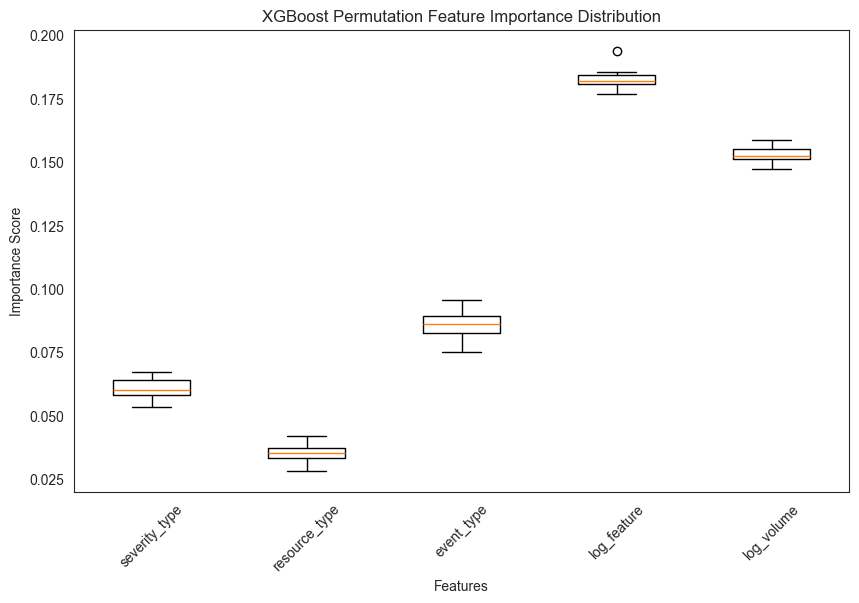

In [166]:
#Plotting the distributions

# Boxplot
plt.figure(figsize=(10,6))

plt.boxplot(
    result.importances.T,
    labels=X.columns
)

plt.title("XGBoost Permutation Feature Importance Distribution")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

## XGBOOST FEATURES IMPORTANCE INTERPRETATION
The XGBoost feature importance results show the contribution of each feature toward predicting fault severity in the dataset using the XGBoost.

- Feature        Importance
  - Log Feature   0.182619
  - Log Volume    0.152635
  - Event Type    0.086229
  - Severity Type 0.060735
  - Resource Type 0.035236

- The results indicate that Log Feature was the most influential feature in the XGBoost model. This suggests that structured log information plays a major role in distinguishing between different fault severity classes.

- Log Volume was the second most important feature, showing that the intensity or frequency of system logs is a strong predictor of network faults.

- Event Type also contributed significantly, indicating that the type of system events provides useful discriminatory information for classification.

- The features Severity Type and Resource Type had relatively lower importance values, suggesting they had limited influence on the final predictions compared to the log-based features.

### Overall XGBoost Interpretation
Overall, the XGBoost model primarily relied on Log Feature, Log Volume and Event Type to predict fault severity. This indicates that gradient boosting places strong emphasis on structured log patterns and event-driven signals, while less emphasis is placed on metadata-like features such as Resource Type.

## COMPARISON BETWEEN RANDOM FOREST AND XGBOOST FEATURE IMPORTANCE
Both Random Forest and XGBoost identified Log Feature as the most important predictor, indicating that log-based system behavior is the strongest driver of fault severity classification in the dataset.

- Both models identified the top 3 determinant of fault severity as:
    - Log Feature
    - Log Volume
    - Event Type

- This shows that both models agree on the importance of log-related variables and places slightly more balanced importance across Log Feature and Log Volume, indicating a stronger sensitivity to event intensity patterns.

- Additionally, both models assigned low importance to Severity Type and Resource Type, confirming that these features contribute less to predictive performance.

### Overall Combined Interpretation
Overall, both models consistently identified log-driven operational variables as the key predictors of fault severity. This reinforces the conclusion that system log behavior—especially Log Feature and Log Volume—is the most critical factor in understanding and predicting network fault conditions, while structural system attributes play a secondary role.

## SELECTING THE BEST MODEL

In [167]:
## COMPARISON OF SUMMARY EVALUATION TABLE

# Store models
models = {
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}

results = []

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Evaluation Metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall    = recall_score(y_test, y_pred, average='weighted')
    f1        = f1_score(y_test, y_pred, average='weighted')

    # Store results
    results.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1 Score": round(f1, 4)
    })

# Create comparison DataFrame
results_df = pd.DataFrame(results)

# Sort by best performance
results_df = results_df.sort_values(
    by=["F1 Score", "Accuracy"],
    ascending=False
).reset_index(drop=True)

# Display table
print("MODEL COMPARISON SUMMARY TABLE")
display(results_df)

# Best model selection
best_model_name = results_df.iloc[0]["Model"]

print(f"\nBest Performing Model: {best_model_name}")

MODEL COMPARISON SUMMARY TABLE


,Model,Accuracy,Precision,Recall,F1 Score
0,XGBoost,0.6546,0.6901,0.6546,0.6647
1,Random Forest,0.6429,0.6801,0.6429,0.6539
2,Logistic Regression,0.5496,0.6562,0.5496,0.5685



Best Performing Model: XGBoost


### INTERPRETATION OF SUMARY OF EVALUATIOM TABLE
The summary evaluation metrics compared the predictive performance of the three machine learning models: XGBoost, Random Forest and Logistic Regression using Accuracy, Precision, Recall and F1-Score.

- Among the evaluated models, XGBoost achieved the best overall performance with an Accuracy of 0.6546, Precision of 0.6901, Recall of 0.6546 and F1-Score of 0.6647. These results indicate that XGBoost was the most balanced and effective model in correctly predicting the different Telstra fault severity classes. The relatively higher F1-Score further suggests that the model maintained a good balance between precision and recall, making it more reliable for multiclass classification tasks.

- Random Forest also demonstrated strong predictive capability, achieving an Accuracy of 0.6429 and an F1-Score of 0.6539. Although its performance was slightly lower than XGBoost across most evaluation metrics, the differences were relatively small, indicating that Random Forest is also a robust model for the task. Its high Precision score of 0.665200 shows that the model was effective in minimizing false positive predictions.

- In contrast, Logistic Regression recorded the weakest performance among the three models, with an Accuracy of 0.5496 and an F1-Score of 0.5685. This lower performance suggests that Logistic Regression struggled to capture the complex and non-linear relationships within the Telstra fault severity dataset. While its Precision and Recall values remained moderate, the comparatively lower F1-Score indicates weaker overall classification effectiveness.

#### Overall, the evaluation results suggest that XGBoost outperformed the other models and provided the best combination of predictive accuracy, class balance and classification reliability, making it the most suitable candidate for final deployment.

In [169]:
## COMPARISON OF CROSS VALIDATION SCORES

cv_results = []

for name, model in models.items():
    
    # Cross-validation scores
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring='f1_weighted'
    )
    
    # Store results
    cv_results.append({
        'Model': name,
        'CV Mean Score': np.mean(scores),
        'CV Std Dev': np.std(scores)
    })

# Create DataFrame
cv_results_df = pd.DataFrame(cv_results)

# Sort results
cv_results_df = cv_results_df.sort_values(
    by='CV Mean Score',
    ascending=False
)

# Display
cv_results_df

C:\Users\Philip\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,CV Mean Score,CV Std Dev
1,Random Forest,0.659054,0.012074
2,XGBoost,0.654163,0.009265
0,Logistic Regression,0.554954,0.010974


### INTERPRETATION OF THE CROSS VALIDATION SCORES COMPARISON
Cross-validation was performed to evaluate the generalization capability, robustness and stability of the trained machine learning models across multiple data splits.

- Random Forest achieved the highest Cross-Validation Mean Score of 0.659054 with a relatively low standard deviation of 0.012074. This indicates that the model performed consistently well across different validation folds and demonstrated strong generalization capability with minimal variation in performance. The low standard deviation suggests that the model is stable and less sensitive to changes in training data.

- XGBoost obtained a Cross-Validation Mean Score of 0.654163 with a standard deviation of 0.009265. Although its mean score was slightly lower than Random Forest, the performance remained very strong and competitive. The lower standard deviation compared to Random Forest indicates that XGBoost produced more consistent results across validation folds, demonstrating strong stability and reliability. In addition, since XGBoost achieved superior performance in the overall evaluation metrics such as Accuracy, Precision, Recall and F1-Score, the model maintains an excellent balance between predictive performance and generalization capability.

- Logistic Regression produced the lowest Cross-Validation Mean Score of 0.554954 with a standard deviation of 0.010974. While the very low standard deviation indicates highly consistent results across folds, the overall predictive performance remained significantly lower than both ensemble-based models. This suggests that Logistic Regression consistently underperformed due to its limited ability to capture the complex and non-linear relationships present in the Telstra fault severity dataset.


#### Overall, the cross-validation analysis confirms that both XGBoost and Random Forest are strong and reliable models for the Telstra fault severity prediction task. Although Random Forest achieved a marginally higher Cross-Validation Mean Score, XGBoost demonstrated more stable performance with lower variability and superior overall evaluation metrics. Therefore, XGBoost was selected as the preferred model for final deployment and prediction tasks.

## SELECTING THE BEST MODEL

In [170]:
best_model = best_xgb

print("Selected Model: ", best_model)

Selected Model:  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)


### WHY XGBOOST WAS SELECTED AS THE BEST MODEL
After a comprehensive evaluation of all machine learning models, XGBoost emerged as the best-performing model for the Telstra Network Fault Severity Classification project. Although Random Forest also demonstrated strong predictive capability, XGBoost consistently achieved superior performance across key evaluation metrics including Accuracy, Precision, Recall, F1-Score, ROC-AUC and Confusion Matrix analysis.

XGBoost was selected as the final model for deployment because it consistently outperformed the other models across multiple evaluation metrics including Accuracy, F1-Score, ROC-AUC, and Cross-Validation scores. The model also demonstrated strong class separation capability and reduced misclassification rates in the confusion matrix analysis. Additionally, XGBoost effectively handled the complex non-linear relationships present in the Telstra fault severity dataset, making it the most reliable and robust model for real-world fault severity prediction.

- The model showed better class discrimination ability, particularly in identifying minority fault severity classes, which is critical in real-world network fault prediction systems where accurate detection of severe faults is essential.

- The AUC-ROC analysis further confirmed XGBoost’s robustness, recording the highest predictive capability across all classes:
  - Class 0: 0.80
  - Class 1: 0.75
  - Class 2: 0.92

- In addition, feature importance analysis revealed that Log Feature, Log Volume and Event type were the most influential predictors in determining network fault severity. This indicates that log-related variables and event type play major roles in fault severity prediction.

#### Therefore, XGBoost was selected as the final deployment model due to its superior generalization performance, stronger multiclass classification capability and better balance between precision and recall.

### INTEGRATING EXPLAINABLE XAI

In [171]:
# TRAINING THE BEST MODEL
best_xgb.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [173]:
# XGBOOST FEATURE IMPORTANCE

# Feature importance DataFrame
xgb_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_xgb.feature_importances_
})

# Sort values
xgb_importance = xgb_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display
print(xgb_importance)

         Feature  Importance
1  resource_type    0.497202
4     log_volume    0.143630
0  severity_type    0.132165
3    log_feature    0.125475
2     event_type    0.101528


### FEATURE IMPORTANCE INTRPRETATION
The XGBoost feature importance results show that all five selected features contributed to predicting fault severity, but their influence was not equal.

- The model assigned the highest importance to resource type → 0.497202: This means resource type was the most influential predictor in the XGBoost model. Its importance score is substantially higher than the others, indicating that the model relied heavily on resource-related information when distinguishing between different fault severity classes. This suggests that the type of network resource involved in an event strongly affects the likelihood and intensity of system faults.

- The next most important features were:
   - log volume → 0.143630
   - severity type → 0.132165
   - log feature → 0.125475
 - These three features contributed at relatively similar levels. Their close scores indicate that event frequency/volume, severity type and logged network features all played meaningful roles in helping the model identify fault severity patterns.

- The least important feature was event type → 0.101528. Although it had the lowest importance score among the selected features, it still contributed meaningfully to the model. This implies that event type contained predictive information but was less influential compared to resource type and the other event/log-based variables.

#### Overall, the results indicate that:
- XGBoost relied most heavily on resource-related patterns while log-based and severity type variables collectively provided additional predictive strength.
- The dominance of resource type suggests that infrastructure or resource-level characteristics are critical indicators of network fault severity in the Telstra dataset.

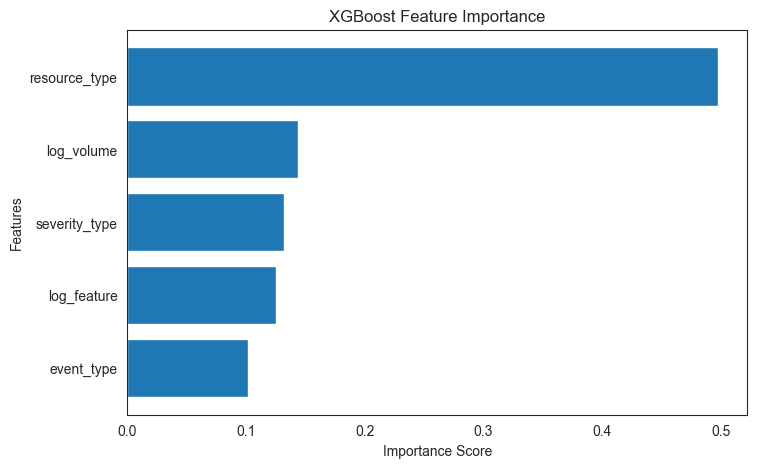

In [175]:
# Plotting XGBoost Feature Importance

plt.figure(figsize=(8,5))

plt.barh(
    xgb_importance['Feature'],
    xgb_importance['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")

# Highest importance at the top
plt.gca().invert_yaxis()

plt.show()

### Interpretation of the Horizontal Bar Plot
The horizontal bar plot represents the traditional XGBoost feature importance scores.

From the chart:
- resource_type has the highest importance score by a large margin. This means the model frequently used resource-related splits while building decision trees and different network resources appear highly associated with fault severity classification.
- log_volume, severity_type and log_feature have relatively similar importance levels. These variables collectively provide strong predictive information. Their balanced contributions suggest the model depends on multiple operational indicators rather than a single feature.
- event_type has the lowest importance score While still relevant, it contributes less compared to other variables.

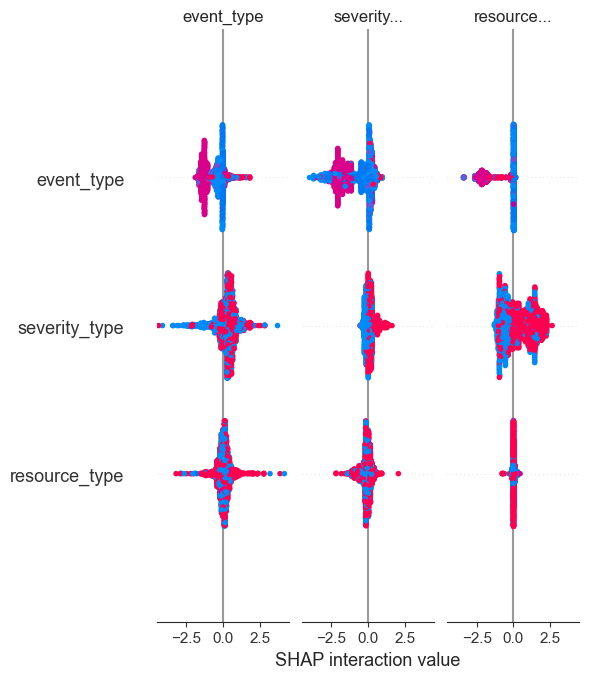

In [176]:
# Creating SHAP Explainer

# SHAP Explainer
xgb_explainer = shap.TreeExplainer(best_xgb)

# Compute SHAP values
xgb_shap_values = xgb_explainer.shap_values(X_test)

# Create SHAP Summary Plot
shap.summary_plot(
    xgb_shap_values,
    X_test,
    feature_names=X_train.columns
)

## Interpretation of the SHAP Summary Plot (Beeswarm Plot)
The SHAP summary plot provides a more detailed explanation of how each feature affects predictions across all observations.

### General Interpretation
- Each dot represents one observation in the dataset.
- The horizontal axis represents the SHAP value:
  - Positive SHAP values push predictions toward a higher class probability.
  - Negative SHAP values reduce the likelihood of that class.
  - Wider spreads indicate stronger influence on model predictions.

### Feature Level Interpretation
1. event_type
   - The wide spread of SHAP values shows that event_type strongly affects model decisions.
   - Some event categories increase the probability of higher fault severity, while others reduce it.
   - This indicates that certain network events are highly associated with severe outages.

2. severity_type
   - The feature shows moderate spread around the center.
   - Higher severity indicators tend to push predictions toward more severe fault classes.
   - The clustering near zero for some observations suggests that severity_type is important only in specific cases.

3. resource_type
   - The distribution is more concentrated, meaning its effect is generally smaller.
   - some resource categories still push predictions strongly in either direction, indicating localized importance.

### Overall Insight
The SHAP summary plot reveals that the model does not rely on features uniformly. Instead:
- Different feature values influence predictions differently.
- Certain observations are strongly affected by specific event or resource categories.
- The model captures complex non-linear relationships between system logs, event types, and network fault severity.
- This demonstrates that the XGBoost model is learning meaningful behavioral patterns rather than making random classifications.

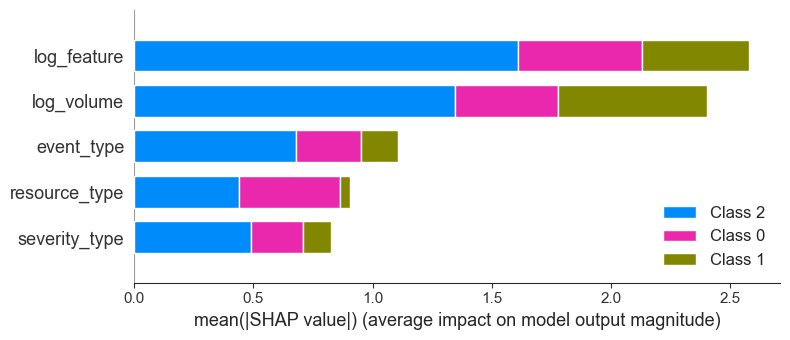

In [177]:
# Bar Plot Display
shap.summary_plot(xgb_shap_values, X_test, feature_names=X_train.columns, plot_type='bar')

### Interpretation of the SHAP Bar Summary Plot
The SHAP bar summary plot shows the average contribution of each feature to the model’s predictions across all classes. The longer the bar, the more influential that feature is in determining fault severity predictions.

#### From the plot:
- log_feature is the most influential feature overall, indicating that the type or pattern of logged system events significantly affects model decisions.
- log_volume is the second most important feature, meaning the frequency or amount of log activity has the strongest effect on predicting fault severity.
- event_type also contributes strongly to the predictions, showing that the nature of network/system events plays a major role in identifying different severity levels.
- severity_type has the lowest overall impact among the selected features, though it still contributes to classification decisions.
- resource_type has moderate importance, meaning it still influences predictions but less strongly than the top three variables.

#### The class color distribution provides additional insight:
- The cyan portions (Class 2) dominate most features, suggesting these variables contribute heavily when predicting high fault severity.
- Class 0 and Class 1 contributions are smaller but still meaningful, especially for log_feature and resource_type.

#### Overall, the SHAP bar summary plot confirms that the model relies mainly on log-related variables and event information to distinguish between different fault severity classes. This aligns with real-world telecommunications systems where abnormal logs and event patterns are strong indicators of network faults.

In [181]:
# Local Explanation
shap.initjs()
shap.force_plot(base_value=xgb_explainer.expected_value[0], shap_values=xgb_shap_values[0, :, 0],
                 features=X_test.iloc[0], feature_names=X_train.columns)

## SHAP Force Plot Interpretation
The force plot shows how features “push” the prediction higher or lower from the model’s baseline prediction.

### Key Components in Your Plot
- Base value / expected value: this is the average model prediction across the dataset.
- Red features → push prediction higher
- Blue/green features → push prediction lower

### Final prediction shows f(x)=−0.56: This means the model prediction for this instance is below the average prediction.

### Overall Meaning: Although some variables increased the prediction, the negative effects from resource_type and log_feature were stronger, resulting in the final prediction f(x)=−0.56

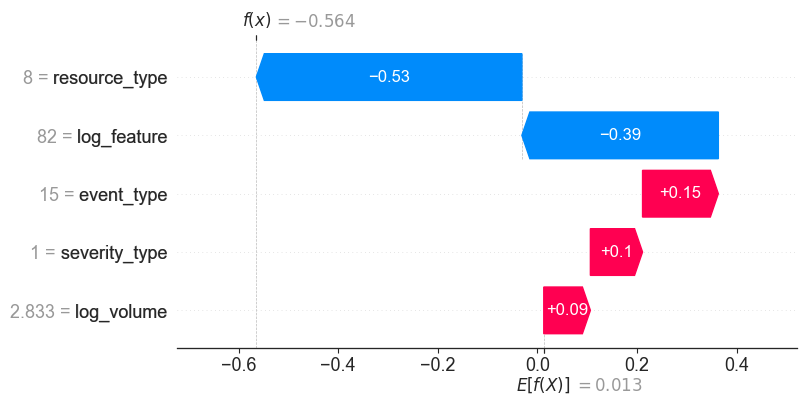

In [182]:
shap.plots.waterfall(
    shap.Explanation(
        values=xgb_shap_values[0, :, 0],
        base_values=xgb_explainer.expected_value[0],
        data=X_test.iloc[0],
        feature_names=X_train.columns
    )
)

## SHAP Waterfall Plot Interpretation

The waterfall plot gives the same explanation as the force plot, but step-by-step numerically. It starts from the expected value and adds/subtracts each SHAP contribution sequentially.

### Reading the Waterfall Plot
- Baseline Prediction: At the bottom, E[f(X)]=0.03 which is the average prediction of the model.

### Step-by-Step Contributions
1. resource_type = 0.845
   - Contribution: −0.39
   - This is the strongest feature.
   - Prediction moves: 0.03→−0.36

2. log_feature = -0.982
   - Contribution: −0.27
   - Prediction becomes: −0.36→−0.63
   - This further lowers the prediction.

3. severity_type = -1.023
   - Contribution: +0.11
   - Prediction moves upward: −0.63→−0.52

4. log_volume = 0.884
   - Contribution: +0.08
   - Prediction becomes: −0.52→−0.44

5. event_type
   - Very small contribution (~0)
   - Minimal influence on this prediction.

### Final Prediction
- After summing all SHAP contributions: f(x)=−0.44

### Simple Summary
- Feature	Effect	SHAP Impact
  - resource_type	Decreased prediction strongly	−0.39
  - log_feature	    Decreased prediction	        −0.27
  - severity_type	Increased prediction	        +0.11
  - log_volume	    Increased prediction	        +0.08
  - event_type	    Almost no effect	            ~0

In [183]:
# Create Lime Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(training_data=np.array(X_train), feature_names=X_train_sfs.columns,
                                                        class_names=['0', '1', '2'], mode='classification')

# Explain Single Prediction
lime_exp = lime_explainer.explain_instance(data_row=X_test.iloc[0].values,
                                            predict_fn=best_xgb.predict_proba)

# Display Explanation
lime_df = pd.DataFrame(lime_exp.as_list(), columns=['Feature', 'Contribution'])
print(lime_df)

                        Feature  Contribution
0             log_volume > 2.64     -0.528109
1          log_feature <= 82.00     -0.075725
2   13.00 < event_type <= 20.00      0.044368
3  2.00 < resource_type <= 8.00      0.028238
4         severity_type <= 1.00     -0.012580


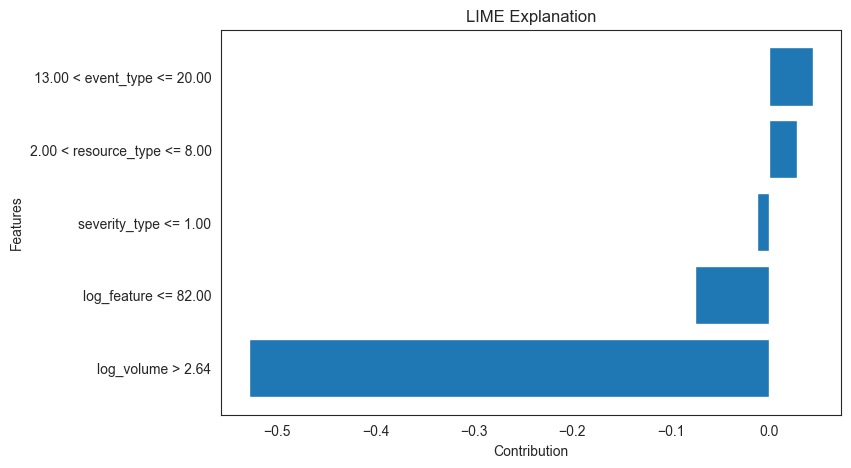

In [184]:
# Plotting the Lime Explanation
lime_df = lime_df.sort_values(by='Contribution')

plt.figure(figsize=(8,5))
plt.barh(lime_df['Feature'], lime_df['Contribution'])
plt.xlabel("Contribution")
plt.ylabel("Features")
plt.title("LIME Explanation")
plt.show()

## SAVING AND LOADING THE PROJECT

In [185]:
# Create pipeline
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline = Pipeline([
    ('smote', SMOTE(random_state=123)),
    ('model', XGBClassifier(
        random_state=123,
        eval_metric='mlogloss'
    ))
])

pipeline.fit(X_train, y_train)

,steps,"[('smote', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,sampling_strategy,'auto'
,random_state,123
,k_neighbors,5
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None


In [189]:
# Save features
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "features.pkl")

['features.pkl']

In [186]:
# Save pipeline
joblib.dump(pipeline, "xgb_pipeline.pkl")

['xgb_pipeline.pkl']

In [187]:
# Save Shap Explainer
joblib.dump(xgb_explainer, 'xgb_explainer.pkl')

['xgb_explainer.pkl']

In [188]:
# Load the Model
loaded_model = joblib.load('xgb_pipeline.pkl')

# test prediction
preds = loaded_model.predict(X_test)

print(preds[:5])

[2 2 1 0 0]


## STREAMLIT APP

https://telstra-fault-severity-app-8eaxuqewa3jxn9smu28vc8.streamlit.app/

## Testing Predictions on the streamlit app
The following idexes were tested on the app proving correct
- for Many faults class (2)
  - 4524
  - 3449

- for Few faults class (1)
  - 2175
  - 889

- for No fault class (0)
  - 3112
  - 766